# QFI from the symmetric logarithmic derivative — prepare, encode, estimate

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 10 — Quantum metrology protocols*

## 1. Introduction and motivation

The previous notebook,
[29 — quantum Fisher information: how fast a quantum state changes under a small parameter shift](../ch10_quantum_metrology_protocols/29_quantum_fisher_information.ipynb),
derived the symmetric logarithmic derivative (SLD), the quantum Fisher information $F_Q$ of a mixed state, and the
Braunstein–Caves theorem ($F_Q$ is the largest classical Fisher information any measurement can produce), and
tested the SLD and its optimal measurement on one full-rank two-qubit state. Three things were left open:

1. **rank-deficient** states (pure states, or the dephased GHZ state of rank two), where the SLD equation has a kernel;
2. many-qubit states stored as density tensors, with noise applied before or after the encoding;
3. the chain from clicks to an error bar for a general measurement, including the finite-sample bias of the estimator.

This notebook supplies all three. It is the workshop notebook of the chapter: we build, from the definition, the generic
pipeline that every later protocol instantiates,

$$\text{prepare }\rho\;\longrightarrow\;\text{encode }\rho_\theta=e^{-i\theta G}\,\rho\,e^{+i\theta G}
  \;\longrightarrow\;\text{measure}\;\longrightarrow\;\text{estimate }\hat\theta ,$$

and we work through its four stages with code and numbers:

* **Encoding.** We apply $e^{-i\theta G}$ to a density *tensor* without ever building a $2^N\times2^N$ matrix, and get
  $\partial_\theta\rho_\theta$ three independent ways (an exact commutator, central finite differences, and forward-mode
  automatic differentiation straight through the encoding function) that must agree.
* **The QFI.** We solve the SLD equation $\partial_\theta\rho=\tfrac12(L\rho+\rho L)$ — a *Lyapunov equation* —
  numerically in the eigenbasis of $\rho$, treat the kernel where $\lambda_m+\lambda_n=0$ explicitly, and evaluate
  $F_Q=\mathrm{Tr}(\rho L^2)$.
* **The optimal measurement** is the projective measurement in the eigenbasis of $L$ (notebook 29, Section 5.3). We
  build it from the numerical $L$ and check that it reaches $F_Q$ while naive readouts do not.
* **Simulated experiments.** We sample outcomes from the exact Born probabilities, estimate $\theta$ by maximum
  likelihood, repeat the experiment tens of thousands of times and compare the measured variance with $1/(M F_Q)$, and
  the measured bias with its first-order prediction, with error bars.

Along the way we run the machine on the states and generators that the rest of the chapter needs: product, GHZ, W, Dicke
and Haar-random states; depolarised, dephased and amplitude-damped GHZ states, with the noise applied **before** and
**after** the encoding (and a clean criterion for when the two coincide); an imperfectly prepared cat state of a spin
chain; and the
generators $J_x$, $J_y$, $J_z$, a staggered field, and a single-site operator.

### What you will learn

*Physics*

* what the symmetric logarithmic derivative is, why it is the natural quantum analogue of the classical score, and why
  $F_Q$ is $\theta$-independent for unitary encoding;
* why mixing states can only destroy metrological power (convexity), and what happens when it does not;
* when a noise channel commutes with the phase encoding — and therefore when "noise before" and "noise after" are the
  same experiment;
* how much of the quantum advantage a sub-optimal but experimentally convenient readout throws away.

*Numerical methods*

* solving a Lyapunov equation by eigendecomposition, and handling a singular kernel without producing NaNs;
* three independent derivatives of an operator-valued function, and what their disagreement would have told us;
* the Bures/fidelity susceptibility as a finite-difference estimator of $F_Q$, with the classic competition between
  truncation error $O(d\theta^2)$ and round-off $O(d\theta^{-2})$;
* maximum-likelihood estimation on a grid, `vmap`-ed over tens of thousands of simulated experiments, with a
  bootstrap-free error bar on a variance, and sampling a sufficient statistic (the counts) instead of individual clicks;
* the $O(1/M)$ bias of maximum likelihood, from a second-order expansion of the score equation.

*Implementation practice*

* density tensors of rank $2N$: ket axes $0\ldots N-1$, bra axes $N\ldots2N-1$, and what "apply an operator from the
  right" means in that language;
* `jax.jacfwd` through a whole physical simulation;
* writing engine-style functions with `MATH` / `IMPLEMENTATION` / `COST` docstrings that later notebooks can reuse verbatim.

### Prerequisites
* [29 — quantum Fisher information: how fast a quantum state changes under a small parameter shift](../ch10_quantum_metrology_protocols/29_quantum_fisher_information.ipynb):
  estimators, classical Fisher information, Cramér–Rao, $F_Q=4\mathrm{Var}(G)$, the SQL and Heisenberg limits;
* [07 — density matrices and quantum channels](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb):
  density tensors, `apply_gate_dm`, Kraus channels, fidelity;
* [08 — measurements](../ch03_matrix_free_engine/08_measurements.ipynb): Born rule, sampling bit strings;
* [01 — JAX](../ch01_computational_toolbox/01_jax_from_scratch.ipynb): `jit`, `vmap`, `jacfwd`, PRNG keys.

**What comes next.** With this machinery in hand the chapter turns to protocols:
[31 — Ramsey interferometry](../ch10_quantum_metrology_protocols/31_ramsey_interferometry.ipynb) (the baseline, end to
end with simulated data), [32 — GHZ interferometry and the Heisenberg limit](../ch10_quantum_metrology_protocols/32_ghz_interferometry_heisenberg_limit.ipynb),
[33 — spin squeezing by one-axis twisting](../ch10_quantum_metrology_protocols/33_spin_squeezing_one_axis_twisting.ipynb),
and [34 — the full one-axis-twisting to GHZ protocol](../ch10_quantum_metrology_protocols/34_oat_to_ghz_full_metrology_protocol.ipynb),
which uses the SLD machinery of this notebook to follow the QFI of a noisy twisted state along its whole evolution.

**Conventions and sizes.** Qubit $q$ = tensor axis $q$; $\vert0\rangle$ is the $+1$ eigenstate of $Z$;
$J_a=\tfrac12\sum_q\sigma^a_q$. The parameter is encoded by $U(\theta)=e^{-i\theta G}$ with $G$ Hermitian. Everything in
this notebook manipulates full density tensors of rank $2N$ and diagonalises $2^N\times2^N$ matrices, so we stay at
$N\le6$ (at $N=7$ a density matrix is still only $128\times128$, but the sweeps get slow).

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # the 52 einsum index labels a-z, A-Z

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and notebook helpers

We need the density-tensor primitives (`apply_gate_dm`, `apply_kraus_dm`, `dm_matrix`, `to_dm`), the state constructors,
the noise channels, `fidelity_dm` for the Bures cross-check, and — as the *reference implementation we must reproduce* —
`qfi_mixed` and `collective_dense`. Everything else is built here.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
SDG = S.conj().T
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)

def apply_gate_dm(rho, U, qubits):
    """Unitary on a density tensor:  rho -> U rho U^dagger.

    MATH   rho'[a..;a'..] = sum_{b,b'} U[a,b] rho[b..;b'..] U^*[a',b']
           i.e. U acts on the KET axis q and the complex conjugate U^* on the BRA axis N+q.
           (A density matrix is "a state vector of 2N qubits": vectorisation |rho>> and
           U (x) U^* acting on it.)
    IMPLEMENTATION  two calls of `apply_gate` -- the same einsum machinery, no new code.
    COST   O(2^k 4^N).
    """
    N = rho.ndim // 2
    rho = apply_gate(rho, U, qubits)                                         # U    on ket axes
    return apply_gate(rho, jnp.conj(jnp.asarray(U)), [N + q for q in qubits])  # U^*  on bra axes

def apply_kraus_dm(rho, kraus, qubits):
    """Quantum channel in Kraus form:  rho -> sum_m K_m rho K_m^dagger,   sum_m K_m^dag K_m = 1.

    EINSUM TRANSLATION  (N=2, channel on qubit 0; g = Kraus index, summed!)
        "gea,gfc,abcd->ebfd"   with operands  K, K^*, rho      [a=ket0, b=ket1, c=bra0, d=bra1; e, f = new ket0, bra0]
    All Kraus branches are summed INSIDE one einsum -- no Python loop over m.
    `kraus` has shape (M, 2^k, 2^k).
    """
    qubits = tuple(int(q) for q in qubits)
    k, N = len(qubits), rho.ndim // 2
    K = jnp.asarray(kraus, dtype=rho.dtype).reshape((-1,) + (2,) * (2 * k))
    n = rho.ndim
    inp = list(_LETTERS[:n])
    new_k, new_b, m = _LETTERS[n:n + k], _LETTERS[n + k:n + 2 * k], _LETTERS[n + 2 * k]
    out = inp.copy()
    for a, b, q in zip(new_k, new_b, qubits):
        out[q], out[N + q] = a, b
    ket_old = "".join(inp[q] for q in qubits)
    bra_old = "".join(inp[N + q] for q in qubits)
    sub = f"{m}{new_k}{ket_old},{m}{new_b}{bra_old},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, K, jnp.conj(K), rho)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def ghz_state(N):
    """GHZ state (|0...0> + |1...1>)/sqrt(2): two non-zero entries of the rank-N tensor."""
    psi = jnp.zeros((2,) * N, dtype=CDTYPE)
    return psi.at[(0,) * N].set(1 / jnp.sqrt(2.0)).at[(1,) * N].set(1 / jnp.sqrt(2.0))

def dicke_state(N, k):
    """Symmetric Dicke state |D_N^k>: equal superposition of all basis states with exactly k ones.
    Implementation: mask of the flat indices with popcount == k, normalised by sqrt(binom(N,k))."""
    idx = np.arange(2 ** N)
    pop = np.array([bin(i).count("1") for i in idx])
    v = (pop == k).astype(np.complex128)
    return jnp.asarray(v / np.linalg.norm(v), dtype=CDTYPE).reshape((2,) * N)

def w_state(N):
    """W state = Dicke state with one excitation: (|10..0> + |01..0> + ... + |0..01>)/sqrt(N)."""
    return dicke_state(N, 1)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)

def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm_dm(rho, keep):
    """Partial trace of a density TENSOR (rank 2N), keeping the qubits `keep`.

    MATH      rho_A[a,a'] = sum_b rho[a,b ; a',b]
    EINSUM    N=2, keep=(0,):  "abAb->aA"   -- the letter b is REPEATED inside one operand and absent
              from the output: that is a trace over that pair of axes.
    """
    keep = tuple(int(q) for q in keep)
    N = rho.ndim // 2
    ket = list(_LETTERS[:N])
    bra = [(_LETTERS[N + q] if q in keep else ket[q]) for q in range(N)]
    sub = f"{''.join(ket)}{''.join(bra)}->{''.join(ket[q] for q in keep)}{''.join(bra[q] for q in keep)}"
    return jnp.einsum(sub, rho).reshape(2 ** len(keep), 2 ** len(keep))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def purity(rho_mat):
    """Tr(rho^2): 1 for pure states, 1/d for the maximally mixed state in dimension d."""
    return jnp.real(jnp.trace(rho_mat @ rho_mat))

def _sqrtm_psd(A):
    """Square root of a positive semi-definite matrix via eigendecomposition: V sqrt(w) V^dag."""
    w, v = jnp.linalg.eigh(A)
    return (v * jnp.sqrt(jnp.clip(w, 0, None))) @ v.conj().T

def fidelity_dm(rho, sigma):
    """Uhlmann fidelity F(rho,sigma) = (Tr sqrt( sqrt(rho) sigma sqrt(rho) ))^2 for dense matrices."""
    s = _sqrtm_psd(rho)
    w = jnp.linalg.eigvalsh(s @ sigma @ s)
    return jnp.sum(jnp.sqrt(jnp.clip(w, 0, None))) ** 2


# ----------------------------------------------------------------------------
# 7. Noise channels (Kraus operators): density matrix and quantum-trajectory forms
# ----------------------------------------------------------------------------
def kraus_depolarizing(p):
    """Depolarising channel  rho -> (1-p) rho + (p/3)(X rho X + Y rho Y + Z rho Z).
    Kraus: sqrt(1-p) 1, sqrt(p/3) X, sqrt(p/3) Y, sqrt(p/3) Z.   Bloch vector shrinks by 1 - 4p/3."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p / 3) * X, jnp.sqrt(p / 3) * Y, jnp.sqrt(p / 3) * Z])

def kraus_dephasing(p):
    """Dephasing (phase-flip) channel  rho -> (1-p) rho + p Z rho Z : coherences rho_01 -> (1-2p) rho_01."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p) * Z])

def kraus_amplitude_damping(g):
    """Amplitude damping (T1 decay |1> -> |0> with probability g):
        K0 = [[1,0],[0,sqrt(1-g)]]   (no decay -- but the amplitude of |1> shrinks: 'no click' is information)
        K1 = [[0,sqrt(g)],[0,0]]     (decay event = sqrt(g) |0><1| = sqrt(g) sigma^+, engine SP)."""
    K0 = jnp.array([[1, 0], [0, jnp.sqrt(1 - g)]], dtype=CDTYPE)
    K1 = jnp.array([[0, jnp.sqrt(g)], [0, 0]], dtype=CDTYPE)
    return jnp.stack([K0, K1])


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out

def dense_hamiltonian(terms, N):
    """Dense 2^N x 2^N matrix for VALIDATION on small N -- built from the matrix-free action:
    column j of H is H|e_j>.   `jax.vmap` applies H to all basis vectors at once."""
    eye = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)
    cols = jax.vmap(lambda e: apply_hamiltonian(terms, e).reshape(-1))(eye)
    return cols.T


# ----------------------------------------------------------------------------
# 11. Collective spins, spin squeezing, quantum Fisher information
# ----------------------------------------------------------------------------
def apply_collective(psi, P, qubits=None):
    """(sum_q P_q)|psi> for a single-qubit operator P -- N einsums, O(N 2^N).  Note: NO factor 1/2 here;
    the collective spin is J_a = (1/2) sum_q sigma^a_q."""
    qubits = range(psi.ndim) if qubits is None else qubits
    out = jnp.zeros_like(psi)
    for q in qubits:
        out = out + apply_gate(psi, P, [q])
    return out

def qfi_pure(psi, P=Z, qubits=None):
    """Quantum Fisher information of a pure state for the phase imprinted by exp(-i theta J),
    J = (1/2) sum_q P_q:
        F_Q = 4 Var(J) = <G^2> - <G>^2   with G = sum_q P_q = 2J.
    Cramer-Rao: Delta theta >= 1/sqrt(M F_Q).  Product states F_Q <= N (standard quantum limit);
    GHZ: F_Q = N^2 (Heisenberg limit).   Matrix-free: |phi> = G|psi>,  <G^2> = <phi|phi>,  <G> = <psi|phi>."""
    phi = apply_collective(psi, P, qubits)
    return jnp.real(jnp.vdot(phi, phi)) - jnp.real(jnp.vdot(psi, phi)) ** 2

def qfi_mixed(rho_mat, G_mat, tol=1e-12):
    """QFI of a MIXED state (symmetric-logarithmic-derivative formula), rho = sum_m l_m |m><m|:
        F_Q = 2 sum_{m,n : l_m+l_n>0} (l_m - l_n)^2/(l_m + l_n) |<m|G|n>|^2       (G = generator, e.g. J).
    Reduces to 4 Var(G) for pure states.  Dense eigendecomposition -> use on small / reduced states."""
    lam, v = jnp.linalg.eigh(rho_mat)
    G = v.conj().T @ G_mat @ v
    num = (lam[:, None] - lam[None, :]) ** 2
    den = lam[:, None] + lam[None, :]
    return 2 * jnp.sum(jnp.where(den > tol, num / jnp.where(den > tol, den, 1.0), 0.0) * jnp.abs(G) ** 2)

def collective_dense(P, n):
    """Dense J = (1/2) sum_q P_q on n qubits (input of `qfi_mixed`), built from the matrix-free action
    on the basis vectors (vmap), exactly like `dense_hamiltonian`."""
    eye = jnp.eye(2 ** n, dtype=CDTYPE).reshape((2 ** n,) + (2,) * n)
    return 0.5 * jax.vmap(lambda e: apply_collective(e, P).reshape(-1))(eye).T


In [3]:
# ==============================================================================
# PLOT STYLE + small helpers used throughout this notebook
# ==============================================================================
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def dm_tensor(mat, N):
    """Inverse of `dm_matrix`: view a 2^N x 2^N matrix as a rank-2N density tensor (ket axes 0..N-1, bra axes N..2N-1)."""
    return jnp.asarray(mat, dtype=CDTYPE).reshape((2,) * (2 * N))


def maximally_mixed(N):
    """The state that knows nothing: rho = 1/2^N on the diagonal, as a density tensor."""
    return dm_tensor(jnp.eye(2 ** N, dtype=CDTYPE) / 2 ** N, N)

## 3. The pipeline, formalised

### 3.1 The four stages

**Prepare.** The laboratory produces a state $\rho$ of $N$ qubits. It need not be pure: gates are imperfect, the preparation
leaves weight in unwanted states, particles are lost. We represent it as a **density tensor** of rank $2N$: the first $N$ axes are
the ket indices $s_0\ldots s_{N-1}$, the last $N$ the bra indices $s'_0\ldots s'_{N-1}$, so that
$\rho[s;s']=\langle s\vert\rho\vert s'\rangle$ (see
[07 — density matrices and quantum channels](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb)).

**Encode.** The unknown parameter enters through a unitary generated by a Hermitian operator $G$:

$$\rho_\theta=U(\theta)\,\rho\,U^\dagger(\theta),\qquad U(\theta)=e^{-i\theta G}. \tag{1}$$

In an interferometer $G$ is a collective spin component and $\theta$ a phase; in a magnetometer $G=\gamma t\,J_z$ and
$\theta$ is the field; in a clock $G=t\,J_z$ and $\theta$ a frequency detuning.

**Measure.** A POVM $\{E_x\}$ turns the state into outcome probabilities by the Born rule,
$p(x\vert\theta)=\mathrm{Tr}(\rho_\theta E_x)$.

**Estimate.** From $M$ outcomes we compute $\hat\theta$, and the Cramér–Rao chain of notebook 29 bounds its error, with
$I(\theta;\{E_x\})$ the classical Fisher information of the measurement (written $F_C$ in notebook 29):

$$\Delta\theta\;\ge\;\frac{1}{\sqrt{M\,I(\theta;\{E_x\})}}\;\ge\;\frac{1}{\sqrt{M\,F_Q[\rho_\theta]}}. \tag{2}$$

### 3.2 The generators we will use

Every generator in this notebook is a **sum of single-qubit terms**,

$$G=\sum_{q}h_q ,\qquad h_q\ \text{acting only on qubit }q, \tag{3}$$

which covers all the cases the chapter needs:

| name | $h_q$ | physical meaning |
|---|---|---|
| collective $J_a$ | $\tfrac12\sigma^a$ on every qubit | a uniform field along $a$; the interferometric phase |
| staggered | $\tfrac12(-1)^q\sigma^a$ | a field alternating between sublattices (antiferromagnetic order parameter) |
| single site | $\tfrac12\sigma^a$ on one qubit only | a local probe: one atom in a gradient |

The terms in Eq. (3) act on different qubits, so they **commute**, and the exponential factorises exactly:

$$U(\theta)=e^{-i\theta\sum_q h_q}=\prod_q e^{-i\theta h_q}. \tag{4}$$

Equation (4) is what makes the encoding cheap: $N$ single-qubit gates, no matrix exponential of anything large. (For a
generator that is *not* a sum of commuting local terms — an interaction, say — one would have to exponentiate properly,
by Trotterisation or a Krylov method; see
[12 — TEBD](../ch05_ground_states_and_unitary_dynamics/12_tebd_trotter_suzuki.ipynb) and
[14 — Krylov](../ch05_ground_states_and_unitary_dynamics/14_krylov_and_integrator_comparison.ipynb).)

### 3.3 From formula to code

We represent a generator as a Python list of pairs `(q, h)` with `h` a $2\times2$ Hermitian matrix — a direct
transcription of Eq. (3). Three things must be implementable:

* **apply $G$** to a tensor: $G\vert\psi\rangle=\sum_q h_q\vert\psi\rangle$ is a sum of `apply_gate` calls;
* **apply $G$ from the right** to a density tensor: $(\rho G)[s;s']=\sum_t\rho[s;t]\,G[t,s']$. Because `apply_gate`
  always contracts the *second* index of the matrix with the tensor axis, acting from the right on bra axis $N+q$ means
  feeding it $G^{\mathsf T}=\overline{G}$ (the transpose, which for a Hermitian $G$ is the complex conjugate);
* **exponentiate** each $h_q$: a $2\times2$ Hermitian eigendecomposition, $h=\sum_k\mu_k\vert k\rangle\langle k\vert
  \Rightarrow e^{-i\theta h}=\sum_k e^{-i\theta\mu_k}\vert k\rangle\langle k\vert$. Exact, general, and $2\times2$ cheap.

In [4]:
# ==============================================================================
# STEP 1: generators as lists of single-qubit terms, and their matrix-free action
# ==============================================================================
def gen_collective(N, P):
    """Collective generator J_a = (1/2) sum_q sigma^a_q  as a list of (qubit, 2x2) terms."""
    return [(q, 0.5 * jnp.asarray(P, dtype=CDTYPE)) for q in range(N)]


def gen_staggered(N, P):
    """Staggered generator (1/2) sum_q (-1)^q sigma^a_q -- a field alternating between the two sublattices."""
    return [(q, 0.5 * (-1.0) ** q * jnp.asarray(P, dtype=CDTYPE)) for q in range(N)]


def gen_single_site(N, q0, P):
    """Single-site generator (1/2) sigma^a_{q0}: a local probe acting on one qubit only."""
    return [(int(q0), 0.5 * jnp.asarray(P, dtype=CDTYPE))]


def apply_generator(t, gen, offset=0, transpose=False):
    """Apply G = sum_q h_q (or its transpose) to the axes `offset + q` of any tensor `t`.

    MATH   (G psi)[.., a, ..] = sum_q sum_b h_q[a,b] psi[.., b, ..]      -- a SUM of local einsums
    IMPLEMENTATION  `offset=0`   -> ket axes of a density tensor (or a state vector): computes G rho
                    `offset=N`, `transpose=True` -> bra axes with h^T: computes rho G
    COST   O(N 2^n) for a rank-n tensor; no 2^N x 2^N operator is ever built.
    """
    out = jnp.zeros_like(t)
    for q, h in gen:
        hh = jnp.transpose(h) if transpose else h
        out = out + apply_gate(t, hh, [offset + q])
    return out


def expm_local(h, theta):
    """exp(-i theta h) for a 2x2 Hermitian h, by eigendecomposition.

    MATH   h = sum_k mu_k |k><k|   =>   exp(-i theta h) = sum_k exp(-i theta mu_k) |k><k| = V diag(e^{-i theta mu}) V^dag
    JAX    `theta` may be traced, so the encoding is differentiable (jax.jacfwd below uses exactly this).
    """
    mu, V = jnp.linalg.eigh(jnp.asarray(h, dtype=CDTYPE))
    return (V * jnp.exp(-1j * theta * mu)) @ V.conj().T


def encode_dm(rho, gen, theta):
    """Unitary encoding of a density TENSOR, Eq. (1) with the factorisation of Eq. (4).

    MATH   rho_theta = U rho U^dag,  U = prod_q exp(-i theta h_q)   (the h_q commute: different qubits)
    COST   2N single-qubit einsums on a rank-2N tensor: O(N 4^N).
    """
    for q, h in gen:
        rho = apply_gate_dm(rho, expm_local(h, theta), [q])
    return rho


def encode_psi(psi, gen, theta):
    """The same encoding for a pure state vector (rank-N tensor): |psi_theta> = U(theta)|psi>."""
    for q, h in gen:
        psi = apply_gate(psi, expm_local(h, theta), [q])
    return psi


def dense_generator(gen, N):
    """Dense 2^N x 2^N matrix of G (VALIDATION and small-N reference only).

    IMPLEMENTATION  apply the matrix-free action to every basis vector at once with `vmap`, then transpose:
                    column j of the matrix is G|j>.   Same trick as the engine's `collective_dense`.
    """
    eye = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)
    return jax.vmap(lambda e: apply_generator(e, gen).reshape(-1))(eye).T


# --- CHECKPOINT: our generators reproduce the engine's collective operators, and the ---------
# --- factorised encoding reproduces a dense matrix exponential -------------------------------
N_CHK = 4
for name, gen, ref in (("J_x", gen_collective(N_CHK, X), collective_dense(X, N_CHK)),
                       ("J_y", gen_collective(N_CHK, Y), collective_dense(Y, N_CHK)),
                       ("J_z", gen_collective(N_CHK, Z), collective_dense(Z, N_CHK))):
    err = max_abs(dense_generator(gen, N_CHK) - ref)
    print(f"dense_generator({name}) vs engine collective_dense: err = {err:.2e}")
    assert err < 1e3 * TOL

for name, gen in (("J_z", gen_collective(N_CHK, Z)), ("J_x", gen_collective(N_CHK, X)),
                  ("staggered Z", gen_staggered(N_CHK, Z)), ("single site X on q=1", gen_single_site(N_CHK, 1, X))):
    Gd = dense_generator(gen, N_CHK)
    w, V = jnp.linalg.eigh(Gd)
    theta = 0.7321
    U_dense = (V * jnp.exp(-1j * theta * w)) @ V.conj().T                # exact exp(-i theta G), 2^N x 2^N
    rho0 = to_dm(haar_state(jax.random.PRNGKey(0), N_CHK))
    lhs = dm_matrix(encode_dm(rho0, gen, theta))                          # factorised, matrix-free
    rhs = U_dense @ dm_matrix(rho0) @ U_dense.conj().T                    # dense reference
    print(f"encode_dm with G = {name:22s}: max|factorised - dense| = {max_abs(lhs - rhs):.2e}")
    assert max_abs(lhs - rhs) < 1e3 * TOL

dense_generator(J_x) vs engine collective_dense: err = 0.00e+00
dense_generator(J_y) vs engine collective_dense: err = 0.00e+00
dense_generator(J_z) vs engine collective_dense: err = 0.00e+00


encode_dm with G = J_z                   : max|factorised - dense| = 1.11e-16
encode_dm with G = J_x                   : max|factorised - dense| = 3.45e-16
encode_dm with G = staggered Z           : max|factorised - dense| = 7.51e-17
encode_dm with G = single site X on q=1  : max|factorised - dense| = 0.00e+00


The factorisation of Eq. (4) reproduces the dense matrix exponential to machine precision for collective, staggered and
single-site generators alike. The left-hand side is cheap: $2N$ contractions of a $2\times2$ matrix with one axis
of the tensor, versus building and exponentiating a $16\times16$ (and, at $N=20$, a $10^6\times10^6$) matrix.

> **JAX practice.** `expm_local` diagonalises a $2\times2$ matrix *inside* a function that `jax.jacfwd` will later
> differentiate. That is fine: `eigh` is differentiable in JAX as long as the eigenvalues are distinct — and here they are
> $\pm\tfrac12$ — and in any case $\theta$ enters only through `jnp.exp`, so the eigendecomposition is a constant as far
> as the derivative with respect to $\theta$ is concerned.

## 4. The derivative $\partial_\theta\rho_\theta$, three ways

Everything below needs the derivative of the encoded state. The same manipulation reappears in every master equation, so
we carry out all of it.

Differentiate Eq. (1) with the product rule, using $\partial_\theta e^{-i\theta G}=-iG\,e^{-i\theta G}=-ie^{-i\theta G}G$
(the generator commutes with its own exponential):

$$\begin{aligned}
\partial_\theta\rho_\theta&=\left(\partial_\theta U\right)\rho\,U^\dagger+U\rho\left(\partial_\theta U^\dagger\right)\\
 &=-iG\,U\rho U^\dagger+U\rho U^\dagger\,(+iG)\\
 &=-i\left(G\rho_\theta-\rho_\theta G\right)\;=\;-i\left[G,\rho_\theta\right].
\end{aligned} \tag{5}$$

Three ways to obtain it numerically, which we will make agree:

1. **the commutator, Eq. (5)** — exact, matrix-free: apply $G$ to the ket axes ($G\rho$), apply $G^{\mathsf T}$ to the
   bra axes ($\rho G$), subtract, multiply by $-i$. Cost $O(N4^N)$;
2. **central finite differences** $\left[\rho_{\theta+\epsilon}-\rho_{\theta-\epsilon}\right]/(2\epsilon)$ — two encodings.
   A Taylor expansion to third order gives the truncation error $\tfrac{\epsilon^2}{6}\,\partial_\theta^3\rho$, and
   each entry of $\rho$ carries a round-off error of about $\delta\approx10^{-16}$ that the division by $2\epsilon$ amplifies,
   so the error of an entry is about $\tfrac{\epsilon^2}{6}c_3+\delta/\epsilon$, with $c_3$ the size of the largest entry of
   $\partial_\theta^3\rho$. It is smallest at $\epsilon_\ast=(3\delta/c_3)^{1/3}$;
3. **`jax.jacfwd` through `encode_dm`** — forward-mode automatic differentiation pushed through the whole physical
   computation (the $2\times2$ eigendecompositions, the complex exponentials, the $2N$ einsums). Exact, no step size;
   forward mode carries a tangent alongside every intermediate value, so it costs a small constant multiple of one
   evaluation of the function.

The third is the interesting one pedagogically: it means that once you can *simulate* an experiment you can *differentiate*
it, with no extra derivation. The first is the one we will use in production, because it is the cheapest and needs no
encoding at all.

In [5]:
# ==============================================================================
# STEP 2: d rho / d theta -- commutator, finite differences, and jax.jacfwd
# ==============================================================================
def drho_commutator(rho, gen):
    """Exact derivative of the encoded state, Eq. (5):  d rho_theta/d theta = -i [G, rho_theta].

    MATH   (G rho)[s;s'] = sum_t G[s,t] rho[t;s']          -> apply G   to the KET axes   (offset 0)
           (rho G)[s;s'] = sum_t rho[s;t] G[t,s']          -> apply G^T to the BRA axes   (offset N)
           d rho = -i (G rho - rho G).
    NOTE   evaluate at the SAME theta as rho: the formula uses rho_theta, not rho_0.
    COST   O(N 4^N), no encoding and no eigendecomposition.
    """
    N = rho.ndim // 2
    G_rho = apply_generator(rho, gen, offset=0)
    rho_G = apply_generator(rho, gen, offset=N, transpose=True)
    return -1j * (G_rho - rho_G)


def drho_findiff(rho0, gen, theta, eps=1e-5):
    """Central finite difference of the encoding: [rho(theta+eps) - rho(theta-eps)] / (2 eps)."""
    return (encode_dm(rho0, gen, theta + eps) - encode_dm(rho0, gen, theta - eps)) / (2 * eps)


def drho_autodiff(rho0, gen, theta):
    """Forward-mode automatic differentiation straight through `encode_dm`. No step size, exact to machine precision."""
    return jax.jacfwd(lambda t: encode_dm(rho0, gen, t))(theta)


# --- CHECKPOINT: the three routes must agree -----------------------------------------
N_D = 4
rho_start = to_dm(ghz_state(N_D))
print(f"{'generator':>22s} {'theta':>6s} | {'|comm - jacfwd|':>16s} {'|findiff - jacfwd|':>19s}")
for gname, gen in (("J_z", gen_collective(N_D, Z)), ("J_x", gen_collective(N_D, X)),
                   ("J_y", gen_collective(N_D, Y)), ("staggered Z", gen_staggered(N_D, Z)),
                   ("single site X (q=2)", gen_single_site(N_D, 2, X))):
    for theta in (0.0, 0.83):
        rho_th = encode_dm(rho_start, gen, theta)
        d_comm = drho_commutator(rho_th, gen)
        d_ad = drho_autodiff(rho_start, gen, theta)
        d_fd = drho_findiff(rho_start, gen, theta)
        e1, e2 = max_abs(d_comm - d_ad), max_abs(d_fd - d_ad)
        print(f"{gname:>22s} {theta:6.2f} | {e1:16.2e} {e2:19.2e}")
        assert e1 < 1e3 * TOL and e2 < 1e-8

# --- the step of the finite difference: truncation (eps^2/6) c_3 against round-off delta/eps ---------
# For GHZ under J_z the only theta-dependent entries are the two coherences (1/2) e^{-+ i N theta}, so the largest
# entry of the third derivative is c_3 = N^3/2 = 32, and the truncation error alone predicts (eps^2/6) * 32.
gen_fd = gen_collective(N_D, Z)
d_exact = drho_commutator(encode_dm(rho_start, gen_fd, 0.83), gen_fd)
c3 = 0.5 * N_D ** 3
print(f"\n{'eps':>8s} | {'max|findiff - exact|':>21s} {'truncation (eps^2/6) c_3':>25s}")
fd_err = {}
for eps in (1e-3, 1e-4, 1e-5, 3e-6, 1e-6, 3e-7, 1e-7, 1e-8):
    fd_err[eps] = max_abs(drho_findiff(rho_start, gen_fd, 0.83, eps) - d_exact)
    print(f"{eps:8.0e} | {fd_err[eps]:21.2e} {eps ** 2 / 6 * c3:25.2e}")
eps_star = (3 * 1e-16 / c3) ** (1 / 3)
print(f"predicted optimum eps_* = (3 delta / c_3)^(1/3) = {eps_star:.1e}  (delta = 1e-16);  "
      f"measured best eps = {min(fd_err, key=fd_err.get):.0e}")
assert abs(fd_err[1e-4] / (1e-8 / 6 * c3) - 1) < 0.01          # truncation-dominated: the eps^2 law holds to 1%
assert fd_err[1e-8] > 10 * fd_err[1e-6]                          # round-off-dominated below the optimum

# --- and a property every derivative of a density matrix must have: it is traceless and Hermitian ---
d = drho_commutator(encode_dm(rho_start, gen_collective(N_D, Z), 0.4), gen_collective(N_D, Z))
dm = dm_matrix(d)
tr_abs = float(jnp.abs(jnp.trace(dm)))
print(f"\nsanity: |Tr(d rho)| = {tr_abs:.2e}   |d rho - (d rho)^dagger| = {max_abs(dm - dm.conj().T):.2e}")
assert tr_abs < 1e3 * TOL and max_abs(dm - dm.conj().T) < 1e3 * TOL

             generator  theta |  |comm - jacfwd|  |findiff - jacfwd|


                   J_z   0.00 |         2.22e-16            5.33e-10
                   J_z   0.83 |         4.74e-16            5.50e-10
                   J_x   0.00 |         0.00e+00            2.92e-11
                   J_x   0.83 |         4.16e-17            2.30e-11
                   J_y   0.00 |         0.00e+00            2.92e-11
                   J_y   0.83 |         4.16e-17            2.30e-11
           staggered Z   0.00 |         0.00e+00            0.00e+00
           staggered Z   0.83 |         0.00e+00            1.14e-11


   single site X (q=2)   0.00 |         0.00e+00            4.17e-12
   single site X (q=2)   0.83 |         0.00e+00            4.35e-12

     eps |  max|findiff - exact|  truncation (eps^2/6) c_3
   1e-03 |              5.33e-06                  5.33e-06
   1e-04 |              5.33e-08                  5.33e-08
   1e-05 |              5.50e-10                  5.33e-10
   3e-06 |              7.84e-11                  4.80e-11
   1e-06 |              1.35e-10                  5.33e-12
   3e-07 |              3.73e-10                  4.80e-13
   1e-07 |              2.35e-09                  5.33e-14
   1e-08 |              1.44e-08                  5.33e-16
predicted optimum eps_* = (3 delta / c_3)^(1/3) = 2.1e-06  (delta = 1e-16);  measured best eps = 3e-06

sanity: |Tr(d rho)| = 0.00e+00   |d rho - (d rho)^dagger| = 0.00e+00


All three routes agree: the commutator and automatic differentiation to machine precision (they compute the same thing by
different means), the finite difference at $\epsilon=10^{-5}$ to between $10^{-12}$ and $6\times10^{-10}$. That default
step lies on the truncation side of the optimum. The step sweep makes this quantitative for GHZ under $J_z$: down to
$\epsilon=10^{-5}$ the error equals the truncation term $\tfrac{\epsilon^2}{6}c_3$ with $c_3=N^3/2=32$ (the GHZ
coherence $\tfrac12e^{-iN\theta}$ has third derivative of modulus $N^3/2$), and below $\epsilon\approx3\times10^{-6}$ round-off
takes over and the error grows again like $1/\epsilon$. The predicted optimum
$\epsilon_\ast=(3\delta/c_3)^{1/3}\approx2\times10^{-6}$ matches the measured best step $3\times10^{-6}$, with an error below $10^{-10}$;
the rule of thumb $\epsilon_\ast\sim\delta^{1/3}\approx5\times10^{-6}$ holds when $c_3$ is of order one. The derivative is
traceless — it must be, since $\mathrm{Tr}\rho_\theta=1$ for all $\theta$ — and Hermitian.

> **Numerical practice.** Each of the three routes tests a different thing. The commutator tests our *algebra*; the finite
> difference tests that `encode_dm` really implements $e^{-i\theta G}$ and not something close to it; `jacfwd` tests that
> the whole pipeline is a differentiable function of $\theta$, which we exploit again in Section 9.3, where `jacfwd`
> applied twice gives the second derivative of the outcome probabilities that fixes the bias of the estimator.

## 5. The symmetric logarithmic derivative

### 5.1 Definition (recap)

Notebook 29, Section 5.2, motivated and defined the **symmetric logarithmic derivative** (SLD), the Hermitian operator
$L_\theta$ solving

$$\partial_\theta\rho_\theta=\frac{1}{2}\left(L_\theta\,\rho_\theta+\rho_\theta\,L_\theta\right). \tag{6}$$

Equation (6) is a **Lyapunov equation**, $AL+LA=B$ with $A=\rho/2$ and $B=\partial_\theta\rho$, solved in the eigenbasis of $A$.

### 5.2 The solution in the eigenbasis of $\rho$

With $\rho=\sum_m\lambda_m\vert m\rangle\langle m\vert$, $(\partial\rho)_{mn}=\langle m\vert\partial_\theta\rho\vert n\rangle$
and $L_{mn}=\langle m\vert L\vert n\rangle$, every matrix element of Eq. (6) decouples (notebook 29, Eq. (45)):

$$\left(\lambda_m+\lambda_n\right)L_{mn}=2\,(\partial\rho)_{mn}. \tag{7}$$

A $d^2$-dimensional linear problem has become $d^2$ scalar divisions — provided we can divide. Two cases:

* **$\lambda_m+\lambda_n>0$:** the element is uniquely determined,

  $$L_{mn}=\frac{2\,(\partial\rho)_{mn}}{\lambda_m+\lambda_n}. \tag{8}$$

* **$\lambda_m+\lambda_n=0$:** since $\lambda\ge0$ this means $\lambda_m=\lambda_n=0$, i.e. both $\vert m\rangle$ and
  $\vert n\rangle$ lie in the **kernel** of $\rho$. Equation (7) then reads $0=2(\partial\rho)_{mn}$. It places no
  constraint on $L_{mn}$, which is left completely arbitrary, and becomes a **consistency condition** on $\partial_\theta\rho$.

### 5.3 The kernel: the condition holds, and the arbitrariness does not matter

*The consistency condition holds.* For unitary encoding we have the commutator, Eq. (5), in the eigenbasis:

$$(\partial\rho)_{mn}=-i\langle m\vert\left(G\rho-\rho G\right)\vert n\rangle=-i\left(\lambda_n-\lambda_m\right)G_{mn}, \tag{9}$$

which vanishes identically whenever $\lambda_m=\lambda_n$, in particular when both are zero. (For a general family
$\rho_\theta$ the same conclusion follows from positivity: $\langle m\vert\rho_\theta\vert m\rangle\ge0$ with equality at
our $\theta$ means that this non-negative function of $\theta$ sits at a minimum, so its derivative $(\partial\rho)_{mm}$
vanishes; the off-diagonal elements inside the kernel then vanish too, because the $2\times2$ principal submatrix
$\begin{pmatrix}0&(\partial\rho)_{mn}\epsilon\\ \overline{(\partial\rho)_{mn}}\epsilon&0\end{pmatrix}+O(\epsilon^2)$ of
$\rho_{\theta+\epsilon}$ would otherwise have a negative eigenvalue at first order in $\epsilon$.)

*The arbitrariness does not matter.* We will see in a moment that $F_Q=\mathrm{Tr}(\rho L^2)=\sum_{m,n}\lambda_m\vert L_{mn}\vert^2$.
An element $L_{mn}$ with $\lambda_m=\lambda_n=0$ is multiplied by $\lambda_m=0$ in that sum and by $\lambda_n=0$ in the
term obtained by swapping $m$ and $n$: it contributes exactly nothing. **We may therefore set the kernel block of $L$ to
zero** — which is what the code does — and every observable conclusion is unaffected.

*One caveat that the algebra hides.* Everything above concerns a **fixed** family $\rho_\theta$ whose rank does not change
with $\theta$ — which is the case throughout this notebook, because a unitary encoding leaves the spectrum untouched
(Section 5.5(a)). If the rank of $\rho_\theta$ *does* change at some $\theta_\ast$ — a model in which one eigenvalue
vanishes exactly at one point — then $F_Q$ computed from Eq. (11) is **discontinuous** at $\theta_\ast$: the terms with
$\lambda_m\to0$ approach a finite limit from either side but are simply absent at $\theta_\ast$ itself. A one-qubit
example is $\rho_\theta=\mathrm{diag}(1-\theta^2,\theta^2)$, for which Eq. (11) gives
$F_Q=4+4\theta^2/(1-\theta^2)\to4$ as $\theta\to0$ but $F_Q=0$ at $\theta=0$, where $\partial_\theta\rho$ vanishes.
At such a point the classical and quantum Cramér–Rao theorems do not hold and the bound built from $F_Q$ can be
violated (Seveso, Albarelli, Genoni and Paris 2020), while the Bures metric gives the continuous extension, i.e. the
limiting value (Šafránek 2017). The noise sweeps of Section 10 do **not** hit this: there the
rank changes as a function of the *noise strength*, not of $\theta$, and $F_Q$ is continuous there — as $p\to0$ the
dephased and depolarised GHZ states return smoothly to the pure-state value $N^2=16$.

> **Common pitfall.** The tempting one-liner `L = 2 * dρ / (λ[:,None] + λ[None,:])` produces `inf` or `NaN` in the kernel
> and silently poisons the trace. In JAX the correct pattern is a *double* `jnp.where`: one to select the safe
> denominator inside the division, one to select the result. Writing `jnp.where(ok, 2*D/den, 0.0)` is not enough — the
> unsafe branch is still evaluated and its NaN propagates through reverse-mode gradients.

### 5.4 The quantum Fisher information from the SLD

The quantum Fisher information is the mean square of the SLD, and notebook 29, Eqs. (46)–(49), expands it in the
eigenbasis of $\rho$ (inserting Eq. (8) and symmetrising the double sum). In this notebook's numbering:

$$F_Q=\mathrm{Tr}\!\left(\rho\,L^2\right)=\sum_{m,n}\lambda_m\left\vert L_{mn}\right\vert^2, \tag{10}$$

$$F_Q=2\sum_{m,n\,:\,\lambda_m+\lambda_n>0}\frac{\left\vert(\partial\rho)_{mn}\right\vert^2}{\lambda_m+\lambda_n}. \tag{11}$$

Equation (11) is completely general: it needs only the state and its derivative, whatever produced them. The same algebra
shows $F_Q=\mathrm{Tr}(L\,\partial_\theta\rho)$, a form that is sometimes more convenient. For unitary encoding Eq. (9)
gives $\left\vert(\partial\rho)_{mn}\right\vert^2=(\lambda_m-\lambda_n)^2\vert G_{mn}\vert^2$ and

$$\boxed{\;F_Q[\rho,G]=2\sum_{m,n\,:\,\lambda_m+\lambda_n>0}\frac{\left(\lambda_m-\lambda_n\right)^2}{\lambda_m+\lambda_n}
  \left\vert\langle m\vert G\vert n\rangle\right\vert^2\;} \tag{12}$$

the formula implemented by the engine's `qfi_mixed`.

### 5.5 Three corollaries

**(a) $F_Q$ does not depend on $\theta$.** The encoded state $\rho_\theta=U\rho U^\dagger$ has the *same* eigenvalues
$\lambda_m$ and eigenvectors $\vert m(\theta)\rangle=U\vert m\rangle$. Its generator matrix elements are

$$\langle m(\theta)\vert G\vert n(\theta)\rangle=\langle m\vert U^\dagger GU\vert n\rangle=\langle m\vert G\vert n\rangle,$$

because $[G,U(\theta)]=0$. Every ingredient of Eq. (12) is $\theta$-independent, hence so is $F_Q$. **We may always work
at $\theta=0$.** (Nothing of the sort is true for the *measurement*: the optimal basis rotates with $\theta$, as we shall
see.)

**(b) Pure states give back $4\,\mathrm{Var}(G)$.** For $\rho=\vert\psi\rangle\langle\psi\vert$ the spectrum is
$\lambda_0=1$, $\lambda_{n>0}=0$, with $\vert 0\rangle=\vert\psi\rangle$. In Eq. (12) a term survives only if exactly one
of $\lambda_m,\lambda_n$ equals $1$, i.e. for the pairs $(0,n)$ and $(n,0)$ with $n\neq0$, each contributing
$\frac{(1-0)^2}{1+0}\vert G_{0n}\vert^2=\vert G_{0n}\vert^2$:

$$F_Q=2\cdot2\sum_{n\neq0}\left\vert\langle\psi\vert G\vert n\rangle\right\vert^2
    =4\left(\sum_{\text{all }n}\left\vert\langle\psi\vert G\vert n\rangle\right\vert^2-\left\vert\langle\psi\vert G\vert\psi\rangle\right\vert^2\right)
    =4\left(\langle G^2\rangle-\langle G\rangle^2\right),$$

using the completeness relation $\sum_n\vert n\rangle\langle n\vert=\mathbb 1$ in the middle step. This is Eq. (75) of
notebook 29. $\square$

**(c) Convexity.** For any mixture, $F_Q\!\left[\sum_ip_i\rho_i,G\right]\le\sum_ip_iF_Q[\rho_i,G]$. The proof takes two
lines since $F_Q$ is the largest classical Fisher information over all measurements (notebook 29, Eq. (58)). Fix a POVM.
The outcome distribution of the mixture is the mixture of the outcome distributions, $p_x=\sum_ip_i\,p^{(i)}_x$, and
likewise for $\partial_\theta p_x$. The function $f(a,b)=a^2/b$ is jointly convex for $b>0$ (its Hessian is
$\tfrac{2}{b^3}\begin{pmatrix}b^2&-ab\\-ab&a^2\end{pmatrix}\succeq0$), so
$I[\text{mixture}]=\sum_xf(\partial_\theta p_x,p_x)\le\sum_ip_i\,I[\rho_i]\le\sum_ip_iF_Q[\rho_i,G]$. Maximising the
left-hand side over the POVM gives the claim (see also Tóth and Apellaniz 2014). We *verify it numerically* in
Section 7. Physically: **classical uncertainty about which state was prepared can only reduce the information
you can extract.** It is also the step that notebook 29 quoted when it extended the standard quantum limit
$F_Q\le N$ from pure product states to all separable mixed states.

## 6. From formula to code: the SLD and the QFI

The implementation is a direct transcription of Eqs. (8), (10) and (11). One `eigh` gives $\lambda$ and the eigenvectors
$V$ (columns); rotating into that basis is $\tilde A=V^\dagger AV$, rotating back is $A=V\tilde AV^\dagger$. The einsum
translation of "rotate a matrix into the eigenbasis" is `"am,ab,bn->mn"` with operands $\overline V$, $A$, $V$ — but since
both operands are plain matrices we simply write it as two matrix products, which is what BLAS wants anyway.

In [6]:
# ==============================================================================
# STEP 3: the symmetric logarithmic derivative and the quantum Fisher information
# ==============================================================================
def sld(rho_mat, drho_mat, tol=1e-12):
    """Symmetric logarithmic derivative L of Eq. (6), returned together with the spectrum of rho.

    MATH   rho = sum_m lam_m |m><m| ;     (lam_m + lam_n) L_mn = 2 <m|drho|n>          [Eq. (7)]
           L_mn = 2 <m|drho|n> / (lam_m + lam_n)   where lam_m + lam_n > tol           [Eq. (8)]
           L_mn = 0                                inside the kernel (free choice, does not affect F_Q)
    IMPLEMENTATION  one Hermitian eigendecomposition; the division is guarded by a DOUBLE jnp.where so
           that the unsafe branch is never evaluated (no inf/NaN, safe under jit/grad).
    COST   O(d^3) with d = 2^N.
    RETURNS  (L, lam, V)  with L a d x d Hermitian matrix, lam ascending, V the eigenvector columns.
    """
    lam, V = jnp.linalg.eigh(rho_mat)
    D = V.conj().T @ drho_mat @ V                       # <m| drho |n>
    den = lam[:, None] + lam[None, :]
    ok = den > tol
    L_eig = jnp.where(ok, 2.0 * D / jnp.where(ok, den, 1.0), 0.0)
    return V @ L_eig @ V.conj().T, lam, V


def qfi_from_sld(rho_mat, drho_mat, tol=1e-12):
    """Quantum Fisher information F_Q = Tr(rho L^2), Eq. (10), for ANY smooth family rho_theta.

    MATH   equivalently F_Q = 2 sum_{m,n} |<m|drho|n>|^2 / (lam_m + lam_n)             [Eq. (11)]
    COST   one eigendecomposition, O(d^3);  the same one as `sld`.
    """
    L, _, _ = sld(rho_mat, drho_mat, tol)
    return jnp.real(jnp.trace(rho_mat @ L @ L))


def qfi_sum_formula(rho_mat, drho_mat, tol=1e-12):
    """The same number via the explicit double sum of Eq. (11) -- an independent code path for validation."""
    lam, V = jnp.linalg.eigh(rho_mat)
    D = V.conj().T @ drho_mat @ V
    den = lam[:, None] + lam[None, :]
    ok = den > tol
    return 2.0 * jnp.sum(jnp.where(ok, jnp.abs(D) ** 2 / jnp.where(ok, den, 1.0), 0.0))


def qfi_unitary(rho_tensor, gen, tol=1e-12):
    """F_Q for UNITARY encoding with generator G: the production routine of this notebook.

    MATH   d rho/d theta = -i [G, rho]  (Eq. 5)  ->  F_Q from Eq. (11)  ==  Eq. (12).
    NOTE   F_Q is theta-independent (Section 5.5a), so no encoding is applied: pass the prepared state.
    COST   O(N 4^N) for the commutator + O(8^N) for the eigendecomposition.
    """
    N = rho_tensor.ndim // 2
    drho = drho_commutator(rho_tensor, gen)
    return qfi_from_sld(dm_matrix(rho_tensor), dm_matrix(drho), tol)


# --- CHECKPOINT 1: the SLD really solves its defining equation, Eq. (6) --------------
N_S = 4
gen_z = gen_collective(N_S, Z)
test_states = {
    "GHZ (pure)": to_dm(ghz_state(N_S)),
    "GHZ + 5% dephasing": None, "GHZ + 5% depolarising": None,
    "maximally mixed": maximally_mixed(N_S),
}


def local_channel(rho, kraus, qubits=None):
    """Apply the same single-qubit channel to each qubit of a density tensor (O(N 4^N))."""
    N = rho.ndim // 2
    for q in (range(N) if qubits is None else qubits):
        rho = apply_kraus_dm(rho, kraus, [q])
    return rho


test_states["GHZ + 5% dephasing"] = local_channel(to_dm(ghz_state(N_S)), kraus_dephasing(0.05))
test_states["GHZ + 5% depolarising"] = local_channel(to_dm(ghz_state(N_S)), kraus_depolarizing(0.05))

print(f"{'state':>24s} | {'residual of Eq. (6)':>20s} {'|L - L^dag|':>13s} {'rank(rho)':>10s}")
for name, rho in test_states.items():
    rm, dm_ = dm_matrix(rho), dm_matrix(drho_commutator(rho, gen_z))
    L, lam, V = sld(rm, dm_)
    residual = max_abs(dm_ - 0.5 * (L @ rm + rm @ L))
    print(f"{name:>24s} | {residual:20.2e} {max_abs(L - L.conj().T):13.2e} "
          f"{int(jnp.sum(lam > 1e-12)):10d}")
    assert residual < 1e3 * TOL and max_abs(L - L.conj().T) < 1e3 * TOL

                   state |  residual of Eq. (6)   |L - L^dag|  rank(rho)


              GHZ (pure) |             6.66e-16      0.00e+00          1
      GHZ + 5% dephasing |             4.44e-16      0.00e+00          2
   GHZ + 5% depolarising |             4.44e-16      0.00e+00         16
         maximally mixed |             0.00e+00      0.00e+00         16


For every state — pure (rank 1), mildly mixed, and maximally mixed (rank $2^N$, where $\partial_\theta\rho=0$ and $L=0$) —
the operator we constructed satisfies the Lyapunov equation to machine precision and is Hermitian. In the pure-state row
the kernel is $15$-dimensional, exactly the situation in which a naive division would have produced `NaN`.

Now the quantitative checks. We compare **four** routes to $F_Q$:

1. `qfi_from_sld` — build $L$, take $\mathrm{Tr}(\rho L^2)$, Eq. (10);
2. `qfi_sum_formula` — the explicit double sum, Eq. (11);
3. the engine's `qfi_mixed` — the specialised unitary formula, Eq. (12);
4. for pure states only, $4\,\mathrm{Var}(G)$ from notebook 29.

In [7]:
# ==============================================================================
# STEP 4: F_Q four ways -- and at several values of theta, to test theta-independence
# ==============================================================================
N_V = 4
pure_zoo = {"product |+>^N": product_state("+" * N_V), "GHZ": ghz_state(N_V), "W": w_state(N_V),
            "Dicke N/2": dicke_state(N_V, N_V // 2), "Haar random": haar_state(jax.random.PRNGKey(0), N_V)}
gens_v = {"J_z": gen_collective(N_V, Z), "J_x": gen_collective(N_V, X)}

print(f"{'state':>15s} {'G':>5s} {'theta':>6s} | {'Tr(rho L^2)':>13s} {'sum formula':>13s} "
      f"{'engine qfi_mixed':>17s} {'4 Var(G)':>11s} {'max err':>9s}")
for sname, psi in pure_zoo.items():
    for gname, gen in gens_v.items():
        Gd = dense_generator(gen, N_V)
        f_var = float(qfi_pure(psi, {"J_z": Z, "J_x": X}[gname]))       # engine: 4 Var(J_a) for pure states
        for theta in (0.0, 0.61):
            rho_th = encode_dm(to_dm(psi), gen, theta)
            rm, dm_ = dm_matrix(rho_th), dm_matrix(drho_commutator(rho_th, gen))
            f1 = float(qfi_from_sld(rm, dm_))
            f2 = float(qfi_sum_formula(rm, dm_))
            f3 = float(qfi_mixed(rm, Gd))
            err = max(abs(f1 - f2), abs(f1 - f3), abs(f1 - f_var))
            print(f"{sname:>15s} {gname:>5s} {theta:6.2f} | {f1:13.6f} {f2:13.6f} {f3:17.6f} {f_var:11.6f} {err:9.1e}")
            assert err < 1e4 * TOL

          state     G  theta |   Tr(rho L^2)   sum formula  engine qfi_mixed    4 Var(G)   max err


  product |+>^N   J_z   0.00 |      4.000000      4.000000          4.000000    4.000000   8.9e-16
  product |+>^N   J_z   0.61 |      4.000000      4.000000          4.000000    4.000000   2.7e-15
  product |+>^N   J_x   0.00 |      0.000000      0.000000          0.000000    0.000000   7.1e-15
  product |+>^N   J_x   0.61 |      0.000000      0.000000          0.000000    0.000000   7.1e-15
            GHZ   J_z   0.00 |     16.000000     16.000000         16.000000   16.000000   1.1e-14
            GHZ   J_z   0.61 |     16.000000     16.000000         16.000000   16.000000   2.8e-14
            GHZ   J_x   0.00 |      4.000000      4.000000          4.000000    4.000000   9.8e-15
            GHZ   J_x   0.61 |      4.000000      4.000000          4.000000    4.000000   8.4e-15
              W   J_z   0.00 |      0.000000      0.000000          0.000000    0.000000   7.7e-34
              W   J_z   0.61 |      0.000000      0.000000          0.000000    0.000000   9.7e-32
          

In [8]:
# ==============================================================================
# STEP 5: the same, for genuinely MIXED states (where 4 Var(G) no longer applies)
# ==============================================================================
N_M = 4
mixed_zoo = {
    "GHZ, dephasing p=0.05": local_channel(to_dm(ghz_state(N_M)), kraus_dephasing(0.05)),
    "GHZ, dephasing p=0.20": local_channel(to_dm(ghz_state(N_M)), kraus_dephasing(0.20)),
    "GHZ, depolarising p=0.10": local_channel(to_dm(ghz_state(N_M)), kraus_depolarizing(0.10)),
    "GHZ, amp. damping g=0.20": local_channel(to_dm(ghz_state(N_M)), kraus_amplitude_damping(0.20)),
    "W, depolarising p=0.10": local_channel(to_dm(w_state(N_M)), kraus_depolarizing(0.10)),
    "0.5 GHZ + 0.5 max.mixed": 0.5 * to_dm(ghz_state(N_M)) + 0.5 * maximally_mixed(N_M),
}
Gz = dense_generator(gen_collective(N_M, Z), N_M)
print(f"{'state':>26s} | {'purity':>8s} {'Tr(rho L^2)':>13s} {'sum formula':>13s} {'engine':>11s} "
      f"{'max err':>9s} {'4 Var(G) (WRONG)':>17s}")
for name, rho in mixed_zoo.items():
    rm, dm_ = dm_matrix(rho), dm_matrix(drho_commutator(rho, gen_collective(N_M, Z)))
    f1, f2 = float(qfi_from_sld(rm, dm_)), float(qfi_sum_formula(rm, dm_))
    f3 = float(qfi_mixed(rm, Gz))
    var4 = 4 * float(jnp.real(jnp.trace(rm @ Gz @ Gz)) - jnp.real(jnp.trace(rm @ Gz)) ** 2)
    err = max(abs(f1 - f2), abs(f1 - f3))
    print(f"{name:>26s} | {float(purity(rm)):8.4f} {f1:13.6f} {f2:13.6f} {f3:11.6f} {err:9.1e} {var4:17.4f}")
    assert err < 1e4 * TOL
    assert f1 <= var4 + 1e4 * TOL

# --- a mixed state for which F_Q = 4 Var(G) after all: dephased GHZ with G = J_x (explained below) ---
Gx = dense_generator(gen_collective(N_M, X), N_M)
rm = dm_matrix(mixed_zoo["GHZ, dephasing p=0.20"])
f_x = float(qfi_mixed(rm, Gx))
var4_x = 4 * float(jnp.real(jnp.trace(rm @ Gx @ Gx)) - jnp.real(jnp.trace(rm @ Gx)) ** 2)
print(f"\nGHZ, dephasing p=0.20, G = J_x:  purity {float(purity(rm)):.4f},  F_Q = {f_x:.6f},  4 Var(J_x) = {var4_x:.6f}")
assert abs(f_x - var4_x) < 1e4 * TOL

                     state |   purity   Tr(rho L^2)   sum formula      engine   max err  4 Var(G) (WRONG)
     GHZ, dephasing p=0.05 |   0.7152      6.887475      6.887475    6.887475   2.7e-15           16.0000
     GHZ, dephasing p=0.20 |   0.5084      0.268739      0.268739    0.268739   2.2e-16           16.0000
  GHZ, depolarising p=0.10 |   0.4531      6.710862      6.710862    6.710862   1.8e-15           13.0133
  GHZ, amp. damping g=0.20 |   0.5091      9.287982      9.287982    9.287982   8.9e-15           11.5200
    W, depolarising p=0.10 |   0.4802      0.000000      0.000000    0.000000   9.9e-32            0.9956
   0.5 GHZ + 0.5 max.mixed |   0.2969      7.111111      7.111111    7.111111   2.7e-15           10.0000

GHZ, dephasing p=0.20, G = J_x:  purity 0.5084,  F_Q = 4.000000,  4 Var(J_x) = 4.000000


Three implementations of the mixed-state QFI agree to $10^{-13}$ or better, and for pure states they all
reduce to $4\,\mathrm{Var}(G)$ exactly as Section 5.5(b) predicts — at $\theta=0$ and at $\theta=0.61$ alike, confirming
the $\theta$-independence of Section 5.5(a).

The last column of the mixed-state table records a common mistake. $4\,\mathrm{Var}(G)$ evaluated on a *mixed* state
(i.e. $4[\mathrm{Tr}(\rho G^2)-\mathrm{Tr}(\rho G)^2]$) is a perfectly well-defined number, it is **not** the quantum
Fisher information, and it is always an over-estimate (the assert checks that too). The reason is physical: the variance
of $G$ in a mixed state contains *classical* fluctuations — uncertainty about which pure state was prepared — that carry no
phase information at all. The gap can be enormous: for the strongly dephased GHZ state the variance formula still reports
$16$, the full Heisenberg value, where the true QFI is $0.269$ — wrong by a factor of sixty. For the equal mixture of
GHZ and white noise (purity $0.30$) it over-reports by $40\%$.

The size of the gap follows from Eq. (12). Writing
$4\,\mathrm{Var}(G)=2\sum_{m,n}(\lambda_m+\lambda_n)\vert G_{mn}\vert^2-4\langle G\rangle^2$ in the same eigenbasis and
using $(\lambda_m+\lambda_n)-\frac{(\lambda_m-\lambda_n)^2}{\lambda_m+\lambda_n}=\frac{4\lambda_m\lambda_n}{\lambda_m+\lambda_n}$,

$$4\,\mathrm{Var}(G)-F_Q=4\Big[\sum_m\lambda_mG_{mm}^2-\Big(\sum_m\lambda_mG_{mm}\Big)^2\Big]
  +8\sum_{m\neq n}\frac{\lambda_m\lambda_n}{\lambda_m+\lambda_n}\vert G_{mn}\vert^2\;\ge\;0 .$$

The first term is the classical variance of the means $G_{mm}$ over the ensemble $\{\lambda_m\}$; the second collects
the matrix elements of $G$ between two *occupied* eigenvectors. Both vanish for a pure state. They also vanish for a
mixed state whose occupied eigenvectors share the same mean of $G$ and are not connected by $G$ — the extra line of the
output is such a case: the dephased GHZ state with $G=J_x$ has $F_Q=4\,\mathrm{Var}(J_x)=N$ at purity $0.51$, for a
reason worked out in Section 10.2.

> **Physics insight.** $F_Q\le4\,\mathrm{Var}(G)$ always, with equality for pure states and for the special mixed
> states just described. The gap measures how much of the spread of $G$ is classical ignorance rather than quantum
> coherence.

## 7. Two more cross-checks: the Bures fidelity susceptibility, and convexity

### 7.1 $F_Q$ as a curvature of the fidelity

The quantum Fisher information is (four times) the **Bures metric** on the space of states. Operationally this means that
neighbouring encoded states become distinguishable at a rate set by $F_Q$:

$$\sqrt{F(\rho_\theta,\rho_{\theta+d\theta})}=1-\frac{F_Q}{8}\,d\theta^2+O(d\theta^4)
  \qquad\Longleftrightarrow\qquad
  F_Q=\lim_{d\theta\to0}\frac{8\left(1-\sqrt{F(\rho_\theta,\rho_{\theta+d\theta})}\right)}{d\theta^2}, \tag{13}$$

where $F(\rho,\sigma)=\left(\mathrm{Tr}\sqrt{\sqrt\rho\,\sigma\sqrt\rho}\right)^2$ is the Uhlmann fidelity **squared**,
which is what the engine's `fidelity_dm` returns; squaring Eq. (13) gives the equivalent statement
$F=1-\tfrac{F_Q}{4}d\theta^2+O(d\theta^4)$ for the squared quantity. Conventions differ from book to book, and the
factor $8$ versus $4$ is exactly the difference between them — always check which one your fidelity routine computes.
For pure states the squared form is immediate:
$F=\vert\langle\psi_\theta\vert\psi_{\theta+d\theta}\rangle\vert^2=1-\mathrm{Var}(G)\,d\theta^2+O(d\theta^4)$ and
$F_Q=4\mathrm{Var}(G)$ (notebook 29, Section 6.4); for mixed states Eq. (13) is a standard
result which we now *test* rather than prove.

This gives a completely independent estimator of $F_Q$: no SLD, no eigen-decomposition of $\partial_\theta\rho$, only two
encoded states and a fidelity. It is also a textbook illustration of the two competing errors in any finite-difference
scheme. The truncation error of Eq. (13) is $O(d\theta^2)$ and shrinks as $d\theta\to0$; but $1-\sqrt F$ is a difference
of two numbers close to $1$, computed with absolute round-off $\varepsilon\approx10^{-16}$, and dividing it by
$d\theta^2$ amplifies that noise by $d\theta^{-2}$. The total error is therefore

$$\text{error}\;\approx\;c_1\,d\theta^2+\frac{c_2\,\varepsilon}{d\theta^2},$$

minimised around $d\theta\approx(\varepsilon)^{1/4}\approx10^{-4}$. The sweep below measures both regimes.

In [9]:
# ==============================================================================
# STEP 6: F_Q from the Bures fidelity susceptibility, Eq. (13), and its convergence
# ==============================================================================
def qfi_bures(rho0_tensor, gen, dtheta, theta=0.0):
    """F_Q from the fidelity of two neighbouring encoded states, Eq. (13).

    MATH   F_Q ~ 8 (1 - sqrt(F(rho_theta, rho_{theta+dtheta}))) / dtheta^2,  error O(dtheta^2).
    COST   two encodings + one Uhlmann fidelity (two eigendecompositions inside `fidelity_dm`).
    """
    a = dm_matrix(encode_dm(rho0_tensor, gen, theta))
    b = dm_matrix(encode_dm(rho0_tensor, gen, theta + dtheta))
    return 8.0 * (1.0 - jnp.sqrt(jnp.clip(fidelity_dm(a, b), 0.0, 1.0))) / dtheta ** 2


N_B = 4
bures_states = {"GHZ (pure)": to_dm(ghz_state(N_B)),
                "GHZ + dephasing p=0.10": local_channel(to_dm(ghz_state(N_B)), kraus_dephasing(0.10)),
                "GHZ + amp. damping g=0.20": local_channel(to_dm(ghz_state(N_B)), kraus_amplitude_damping(0.20))}
DTHETAS = np.array([3e-1, 1e-1, 3e-2, 1e-2, 3e-3, 1e-3, 3e-4, 1e-4, 3e-5, 1e-5, 3e-6, 1e-6])
bures_err = {}
print(f"{'state':>26s} | {'F_Q (SLD)':>11s} | best Bures estimate and its relative error")
for name, rho in bures_states.items():
    f_ref = float(qfi_unitary(rho, gen_collective(N_B, Z)))
    vals = np.array([float(qfi_bures(rho, gen_collective(N_B, Z), float(d))) for d in DTHETAS])
    rel = np.abs(vals - f_ref) / f_ref
    bures_err[name] = (vals, rel, f_ref)
    j = int(np.argmin(rel))
    print(f"{name:>26s} | {f_ref:11.6f} | best at dtheta = {DTHETAS[j]:8.1e}: "
          f"{vals[j]:11.6f}  (relative error {rel[j]:.1e})")
    assert rel.min() < 1e-6

                     state |   F_Q (SLD) | best Bures estimate and its relative error


                GHZ (pure) |   16.000000 | best at dtheta =  1.0e-04:   16.000000  (relative error 1.6e-08)
    GHZ + dephasing p=0.10 |    2.684355 | best at dtheta =  3.0e-04:    2.684354  (relative error 8.2e-08)
 GHZ + amp. damping g=0.20 |    9.287982 | best at dtheta =  3.0e-04:    9.287983  (relative error 1.7e-07)


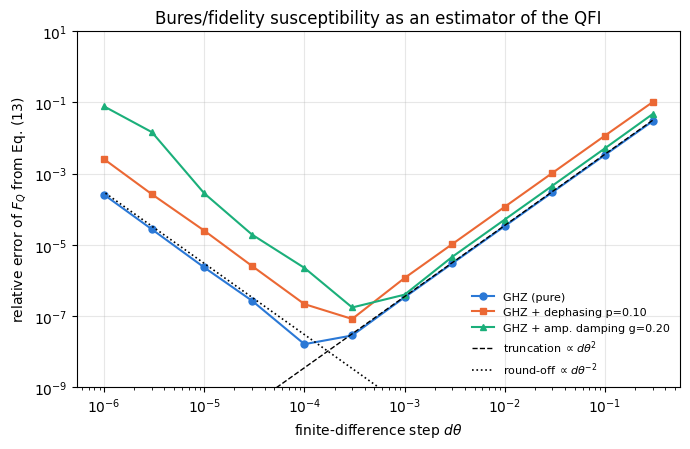

In [10]:
# ==============================================================================
# FIGURE: truncation error versus round-off in the Bures estimator
# ==============================================================================
fig, ax = plt.subplots(figsize=(7.0, 4.6))
for k, (name, (vals, rel, f_ref)) in enumerate(bures_err.items()):
    ax.loglog(DTHETAS, np.clip(rel, 1e-17, None), MARKERS[k] + "-", color=PALETTE[k], ms=5, label=name)
ax.loglog(DTHETAS, 0.35 * DTHETAS ** 2, "k--", lw=1, label=r"truncation $\propto d\theta^{2}$")
ax.loglog(DTHETAS, 3e-16 / DTHETAS ** 2, "k:", lw=1.2, label=r"round-off $\propto d\theta^{-2}$")
ax.set_xlabel(r"finite-difference step $d\theta$")
ax.set_ylabel(r"relative error of $F_Q$ from Eq. (13)")
ax.set_title("Bures/fidelity susceptibility as an estimator of the QFI")
ax.legend(fontsize=8); ax.set_ylim(1e-9, 1e1)
fig.tight_layout(); plt.show()

The measured curves are the classic V of finite differencing: on the right the error follows the $d\theta^2$ truncation
line of Eq. (13), on the left it climbs *parallel* to the $d\theta^{-2}$ round-off line — displaced upwards for the two
mixed states, whose fidelity costs two extra eigendecompositions and therefore carries a larger round-off constant —
and the minimum sits where the two effects cross.
At the optimum all three states reproduce the SLD value of $F_Q$ to better than one part in $10^{6}$ — an independent
confirmation that our $L$ is correct, obtained without ever writing down an SLD.

> **Numerical practice.** Eq. (13) connects the QFI to a quantity that can be estimated in experiments: for pure states the
> fidelity is an overlap, accessible by a swap test or by randomised measurements. For mixed states those protocols
> measure overlaps such as $\mathrm{Tr}(\rho\sigma)$ rather than the Uhlmann fidelity, and give bounds on $F_Q$ instead of
> its value. Numerically the SLD route is exact and cheaper, so Eq. (13) serves here as an independent check.

### 7.2 Convexity

Section 5.5(c) claimed $F_Q\!\left[\,q\rho_1+(1-q)\rho_2\,\right]\le qF_Q[\rho_1]+(1-q)F_Q[\rho_2]$. We test it on two
families: a GHZ state mixed with white noise, and a GHZ state mixed with a W state.

   GHZ + maximally mixed: F_Q(rho_1) =  16.000, F_Q(rho_2) =   0.000, F_Q at q=1/2 =   7.111  (linear interpolation would give   8.000)
           GHZ + W state: F_Q(rho_1) =  16.000, F_Q(rho_2) =   0.000, F_Q at q=1/2 =   8.000  (linear interpolation would give   8.000)
    GHZ + product |0..0>: F_Q(rho_1) =  16.000, F_Q(rho_2) =   0.000, F_Q at q=1/2 =   4.000  (linear interpolation would give   8.000)


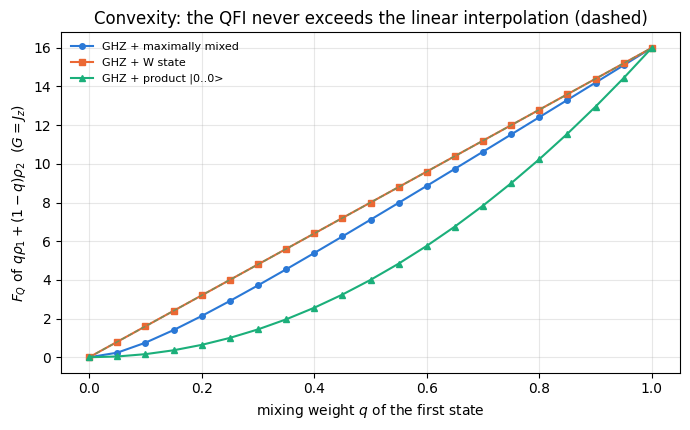

In [11]:
# ==============================================================================
# STEP 7: convexity of the QFI
# ==============================================================================
N_C = 4
gen_c = gen_collective(N_C, Z)
conv_pairs = {"GHZ + maximally mixed": (to_dm(ghz_state(N_C)), maximally_mixed(N_C)),
              "GHZ + W state": (to_dm(ghz_state(N_C)), to_dm(w_state(N_C))),
              "GHZ + product |0..0>": (to_dm(ghz_state(N_C)), to_dm(product_state("0" * N_C)))}
QS = np.linspace(0.0, 1.0, 21)
conv_data = {}
for name, (r1, r2) in conv_pairs.items():
    f1, f2 = float(qfi_unitary(r1, gen_c)), float(qfi_unitary(r2, gen_c))
    vals = np.array([float(qfi_unitary(q * r1 + (1 - q) * r2, gen_c)) for q in QS])
    conv_data[name] = (vals, f1, f2)
    assert np.all(vals <= QS * f1 + (1 - QS) * f2 + 1e-8)
    print(f"{name:>24s}: F_Q(rho_1) = {f1:7.3f}, F_Q(rho_2) = {f2:7.3f}, "
          f"F_Q at q=1/2 = {vals[10]:7.3f}  (linear interpolation would give {(f1 + f2) / 2:7.3f})")

fig, ax = plt.subplots(figsize=(7.0, 4.4))
for k, (name, (vals, f1, f2)) in enumerate(conv_data.items()):
    ax.plot(QS, vals, MARKERS[k] + "-", color=PALETTE[k], ms=4, label=name)
    ax.plot(QS, QS * f1 + (1 - QS) * f2, "--", color=PALETTE[k], lw=1, alpha=0.6)
ax.set_xlabel(r"mixing weight $q$ of the first state")
ax.set_ylabel(r"$F_Q$ of $q\rho_1+(1-q)\rho_2$  ($G=J_z$)")
ax.set_title("Convexity: the QFI never exceeds the linear interpolation (dashed)")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

The solid curves stay on or below the dashed straight lines, as convexity demands, and the assert makes that a test rather
than a picture. (The three dashed lines coincide, since every pair runs from $F_Q=0$ to $16$, and lie under the GHZ + W
curve.) Each of the three families shows a different mechanism.

* **GHZ mixed with white noise** is strictly convex: at $q=1/2$ the mixture retains $7.11$ out of the
  $8.00$ that linear interpolation would suggest, and the curve bends further down at small $q$.
* **GHZ mixed with a W state** is *exactly linear*. That is not an accident and not a violation: the two states have
  orthogonal supports (GHZ lives on the strings $0\cdots0$ and $1\cdots1$, W on the weight-one strings) **and** the
  generator $J_z$ does not connect those supports, being diagonal. The mixture therefore splits into two independent
  blocks, and Eq. (11) — a sum over pairs of eigenvectors — adds their contributions with weights $q$ and $1-q$ exactly.
  Had $G$ connected the two supports, a pair $(m,n)$ with $m$ in one and $n$ in the other, with weights $a=q\lambda_m$
  and $b=(1-q)\lambda_n$, would contribute $2(a-b)^2/(a+b)\,\vert G_{mn}\vert^2$ to the mixture but
  $2(a+b)\,\vert G_{mn}\vert^2$ to the linear interpolation (there each state sees the other's support as kernel), and
  $(a-b)^2/(a+b)<a+b$ whenever $ab>0$ — the identity behind the gap formula of Section 6. Convexity is saturated when the mixed states have
  orthogonal supports that the generator does not connect: a side channel could then tell you which state you hold
  without disturbing the phase, and mixing costs nothing.
* **GHZ mixed with $\vert0\cdots0\rangle$** follows the parabola $F_Q=N^2q^2$ ($4.000$ at $q=\tfrac12$). The admixture
  lives in the same two-dimensional span of $\vert0\cdots0\rangle$ and $\vert1\cdots1\rangle$ that carries the GHZ
  coherence. In that span the state is an effective qubit whose coherence is $q/2$, so its Bloch vector has transverse
  length $q$; $J_z$ acts there as $\tfrac N2\sigma^z$, and a qubit rotated by $\tfrac N2\sigma^z$ has $F_Q=N^2$ times the
  squared transverse Bloch length (Exercise 1 is the same calculation with the axes relabelled). The admixture adds population without coherence.

## 8. The optimal measurement

### 8.1 Why the eigenbasis of $L$ is optimal

**Theorem (Braunstein and Caves 1994).** For every POVM $\{E_x\}$, the classical Fisher information of the outcome
distribution obeys $I(\theta;\{E_x\})\le F_Q$, and the projective measurement in the eigenbasis of $L_\theta$ attains it.

The proof is in notebook 29, Section 5.3, Eqs. (50)–(57): the Cauchy–Schwarz inequality in the Hilbert–Schmidt inner
product bounds every outcome's contribution, and in the eigenbasis $\{\vert\ell_x\rangle\}$ of $L$ Eq. (6) gives
$\partial_\theta p_x=\ell_x\,p_x$, so that $I=\sum_x\ell_x^2\,p_x=\mathrm{Tr}(\rho L^2)=F_Q$. Three points are not
visible in the algebra:

* the optimal basis depends on $\theta$ (through $L_\theta=U(\theta)L_0U^\dagger(\theta)$), so the measurement is only
  **locally optimal** — you must already know $\theta$ roughly in order to measure it optimally. In practice one runs an
  adaptive scheme, or accepts a fixed basis and the loss it entails;
* when $\rho$ is rank-deficient, $L$ is not unique (Section 5.3) and neither is its eigenbasis: the kernel block we set
  to zero contributes $2^N-\mathrm{rank}(\rho)$ degenerate eigenvalues $\ell=0$, so *any* orthonormal basis of that
  subspace may be returned by `eigh`. The attainability proof uses only Eq. (6) and $L\vert\ell_x\rangle=\ell_x\vert\ell_x\rangle$,
  both of which hold for every such choice, so every one of them attains $F_Q$;
* outcomes with $p_x=0$ need care in the code: they contribute $0$ to the Fisher information (their derivative vanishes
  too), but $0/0$ in floating point does not.

### 8.2 Code, and three measurements compared

We compare, for a fixed state and generator:

* the **SLD basis** (optimal, by the theorem);
* the **computational ($Z$) basis** — the natural hardware readout;
* the **$X$ basis** (a Hadamard on every qubit, then $Z$) — the parity-style readout that GHZ interferometry actually uses.

For each we compute the exact probabilities $p(x\vert\theta)=\langle x\vert\rho_\theta\vert x\rangle$ and their exact
derivatives, and evaluate the classical Fisher information $\sum_x(\partial_\theta p_x)^2/p_x$.

In [12]:
# ==============================================================================
# STEP 8: probabilities, their derivatives, and the Fisher information of a basis
# ==============================================================================
def basis_probs(rho_mat, U_basis):
    """Born probabilities of the projective measurement whose basis vectors are the COLUMNS of U_basis.

    MATH   p_x = <x|rho|x> with |x> = column x of U     ->   einsum("ax,ab,bx->x", conj(U), rho, U)
    """
    return jnp.real(jnp.einsum("ax,ab,bx->x", U_basis.conj(), rho_mat, U_basis))


def fisher_of_basis(rho_mat, drho_mat, U_basis, tol=1e-12):
    """Classical Fisher information of a projective measurement in the basis given by the columns of U_basis.

    MATH   I = sum_x (d p_x/d theta)^2 / p_x   with   p_x = <x|rho|x>,  d p_x = <x|drho|x>
    JAX    outcomes with p_x = 0 are masked out by a double `jnp.where` (they contribute exactly 0).
    """
    p = basis_probs(rho_mat, U_basis)
    dp = basis_probs(drho_mat, U_basis)
    ok = p > tol
    return jnp.sum(jnp.where(ok, dp ** 2 / jnp.where(ok, p, 1.0), 0.0))


def kron_power(M, N):
    """M (x) M (x) ... (x) M, N factors -- the 2^N x 2^N matrix of a single-qubit basis rotation applied to every qubit."""
    out = jnp.eye(1, dtype=CDTYPE)
    for _ in range(N):
        out = jnp.kron(out, jnp.asarray(M, dtype=CDTYPE))
    return out


# PARAMETERS ------------------------------------------------------------------
N_MEAS = 4
THETA_0 = 0.30                      # working point at which the optimal measurement is designed
GAMMA_AD = 0.20                     # amplitude damping applied to the GHZ state before encoding
# -----------------------------------------------------------------------------
gen_meas = gen_collective(N_MEAS, Z)
rho_prep = local_channel(to_dm(ghz_state(N_MEAS)), kraus_amplitude_damping(GAMMA_AD))
rho_theta = encode_dm(rho_prep, gen_meas, THETA_0)
rm0, dm0 = dm_matrix(rho_theta), dm_matrix(drho_commutator(rho_theta, gen_meas))
L0, lam0, _ = sld(rm0, dm0)
F_Q = float(qfi_from_sld(rm0, dm0))
_, U_SLD = jnp.linalg.eigh(L0)                       # columns = eigenvectors of the SLD
U_Z = jnp.eye(2 ** N_MEAS, dtype=CDTYPE)             # computational basis
U_X = kron_power(H, N_MEAS)                          # Hadamard on every qubit, then read Z

print(f"state: GHZ_{N_MEAS} after amplitude damping g={GAMMA_AD}, encoded with G=J_z at theta_0={THETA_0}")
print(f"purity = {float(purity(rm0)):.4f},  rank = {int(jnp.sum(lam0 > 1e-12))},  F_Q = {F_Q:.6f}\n")
print(f"{'measurement basis':>22s} | {'classical Fisher info':>21s} {'I / F_Q':>9s} {'outcomes with p>0':>18s}")
for name, U in (("SLD eigenbasis", U_SLD), ("computational (Z)", U_Z), ("X basis (H on all)", U_X)):
    I_val = float(fisher_of_basis(rm0, dm0, U))
    n_out = int(jnp.sum(basis_probs(rm0, U) > 1e-12))
    print(f"{name:>22s} | {I_val:21.6f} {I_val / F_Q:9.4f} {n_out:18d}")
assert abs(float(fisher_of_basis(rm0, dm0, U_SLD)) - F_Q) < 1e4 * TOL
assert float(fisher_of_basis(rm0, dm0, U_X)) < F_Q
assert float(fisher_of_basis(rm0, dm0, U_Z)) < 1e4 * TOL

state: GHZ_4 after amplitude damping g=0.2, encoded with G=J_z at theta_0=0.3
purity = 0.5091,  rank = 16,  F_Q = 9.287982

     measurement basis | classical Fisher info   I / F_Q  outcomes with p>0
        SLD eigenbasis |              9.287982    1.0000                 16
     computational (Z) |              0.000000    0.0000                 16
    X basis (H on all) |              6.016679    0.6478                 16


The table follows the theorem. The SLD eigenbasis delivers a classical Fisher information equal to $F_Q$ to machine
precision. The computational basis delivers **zero**: the encoding $e^{-i\theta J_z}$ is diagonal in that basis, so it
only multiplies amplitudes by phases and the populations $p(s)=\langle s\vert\rho_\theta\vert s\rangle$ do not depend on
$\theta$ at all. No estimator, however clever, can extract a phase from data that does not contain it. The $X$ basis — the
readout a GHZ interferometer actually uses — sits in between, recovering about $65\%$ of the quantum bound for this noisy
state. (On a *pure* GHZ state the $X$ basis is exactly optimal at every $\theta$ except the fringe extrema: the parity
probabilities are $p_\pm=2^{-N}(1\pm\cos N\theta)$, so $I=\tfrac12N^2\sin^2N\theta\left[\frac{1}{1+\cos N\theta}+
\frac{1}{1-\cos N\theta}\right]=N^2=F_Q$ whenever $\sin N\theta\neq0$, and $I=0$ at $\theta=k\pi/N$, where the fringe is
stationary. Here it is the amplitude damping that pushes $I$ below $F_Q$ everywhere.)

The $\theta$-dependence of the three curves is what the qualifier "locally optimal" refers to.

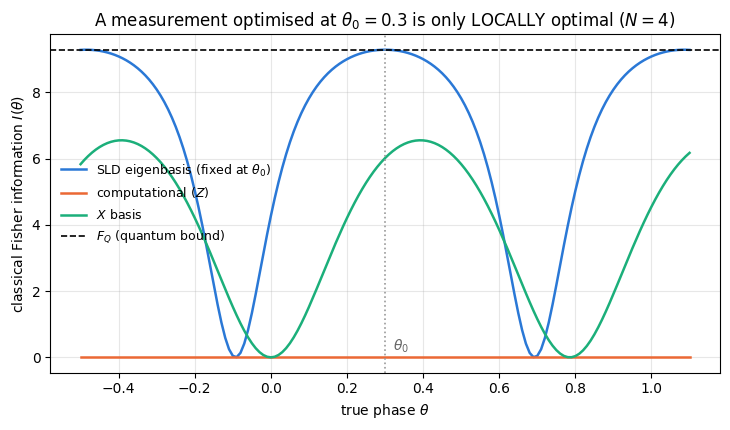

In [13]:
# ==============================================================================
# STEP 9: the Fisher information of a FIXED measurement as theta moves away from theta_0
# ==============================================================================
THETA_SCAN = np.linspace(THETA_0 - 0.8, THETA_0 + 0.8, 161)
scan = {}
for name, U in (("SLD eigenbasis (fixed at $\\theta_0$)", U_SLD), ("computational ($Z$)", U_Z),
                ("$X$ basis", U_X)):
    vals = []
    for th in THETA_SCAN:
        r = encode_dm(rho_prep, gen_meas, float(th))
        vals.append(float(fisher_of_basis(dm_matrix(r), dm_matrix(drho_commutator(r, gen_meas)), U)))
    scan[name] = np.array(vals)

fig, ax = plt.subplots(figsize=(7.4, 4.4))
for k, (name, vals) in enumerate(scan.items()):
    ax.plot(THETA_SCAN, vals, "-", color=PALETTE[k], lw=1.8, label=name)
ax.axhline(F_Q, color="k", ls="--", lw=1.2, label=r"$F_Q$ (quantum bound)")
ax.axvline(THETA_0, color="0.6", ls=":", lw=1.2)
ax.text(THETA_0 + 0.02, 0.2, r"$\theta_0$", fontsize=10, color="0.4")
ax.set_xlabel(r"true phase $\theta$"); ax.set_ylabel(r"classical Fisher information $I(\theta)$")
ax.set_title(f"A measurement optimised at $\\theta_0={THETA_0}$ is only LOCALLY optimal ($N={N_MEAS}$)")
ax.legend(fontsize=9)
fig.tight_layout(); plt.show()

The SLD curve touches the quantum bound at $\theta_0$: move the true phase away and the fixed basis loses information,
symmetrically, falling to **zero** exactly half-way to the next revival, at $\theta_0\pm\pi/(2N)$, i.e. at
$\theta=-0.093$ and $\theta=0.693$, where the
interference fringe reaches an extremum and the outcome probabilities are stationary in $\theta$. The statement "the SLD
basis is optimal" holds at the design point and at its revivals.

The curve is *periodic*, with period $\pi/N$: the measurement built at $\theta_0$ is equally optimal at
$\theta_0+k\pi/N$, and a direct evaluation gives $I=9.28798186=F_Q$ at $\theta=-0.485,\,0.300,\,1.085$ to thirteen
digits. "Locally optimal" therefore means *locally in $\theta$ modulo $\pi/N$* — which is also why the maximum-likelihood
search of Section 9 must be confined to a window of that width, otherwise the likelihood has several equally good peaks.
In a real experiment one works in two stages — a coarse estimate first, then a measurement optimised around it — or
accepts a convenient fixed basis such as $X$ and pays the difference. The $Z$ curve is flat at zero, as it must be.

## 9. Simulating the experiment: from clicks to an error bar

Everything so far was exact. Now we *run the experiment*: draw $M$ outcomes from the exact Born distribution, estimate
$\theta$ by maximum likelihood, and repeat the whole experiment $R$ times to measure the variance of the estimator.

### 9.1 The estimator

With $M$ independent shots producing counts $n_x$ (so $\sum_xn_x=M$), the log-likelihood of a candidate phase is

$$\log\mathcal{L}(\theta)=\sum_x n_x\log p(x\vert\theta), \tag{14}$$

and the maximum-likelihood estimate is $\hat\theta=\arg\max_\theta\log\mathcal{L}(\theta)$. We maximise on a fine grid,
which is robust, trivially `vmap`-able, and makes the **phase ambiguity** explicit: $p(x\vert\theta)$ for a GHZ-like state
oscillates with period $2\pi/N$ in $\theta$, so a search over the whole circle would let the estimator lock onto a
neighbouring fringe. We take the window $\theta_0\pm\pi/(2N)$ — a quarter of a period on each side, i.e. the width
$\pi/N$ over which the Fisher information of Section 8.2 is periodic. The signal is *not* monotone across the whole
window (the parity turns over at $\theta=0$, which for $\theta_0=0.3$, $N=4$ lies inside it), but the likelihood is
unimodal there, which is what the estimator needs. A window wider than $\pi/N$ would admit a second, equally high peak.

### 9.2 The error bar on a variance, and independent random numbers

Equation (14) depends on the data only through the counts $n_x$: they are a **sufficient statistic**. Their joint
distribution is multinomial, $(n_x)\sim\mathrm{Mult}\!\left(M;\{p(x\vert\theta)\}\right)$, so an experiment can be
simulated by drawing the counts directly instead of drawing $M$ individual clicks and histogramming them. The two are
the same random experiment; the click version costs memory proportional to $R\times M\times2^N$, the count version
$R\times2^N$. We validate the count sampler against clicks once and then use it for production.

We compare the measured $\mathrm{Var}(\hat\theta)$ over $R$ experiments with the Cramér–Rao prediction $1/(M\,I)$. A
measured variance is itself a random number: for approximately Gaussian estimates its relative standard error is
$\sqrt{2/(R-1)}$, which is $0.63\%$ for the $R=50\,000$ used below and $3.2\%$ for $R=2000$. The mean has standard error
$\sqrt{\mathrm{Var}/R}$. Both are drawn as error bars. The choice of $R$ matters: the effects we want to see — the
$O(1/M)$ excess of the maximum-likelihood variance over the Cramér–Rao value, and the $O(1/M)$ bias — are a few per
cent of the variance and a fraction of the standard deviation respectively, and at $R=2000$ they are buried in the
Monte-Carlo noise except at the smallest $M$.

Every row of the tables below gets its **own** PRNG key (`jax.random.fold_in` of a base key with the row's labels).
Reusing one key for all rows, as is tempting, makes the rows statistically dependent: a single fluctuation of the
random numbers then shifts the whole column coherently, and a smooth-looking trend across $M$ or across $\theta$ can be
one correlated fluctuation.

### 9.3 The bias at finite $M$

Maximum likelihood is consistent but not unbiased. The size of the bias follows from expanding the score equation. Let
$\ell_x(\theta)=\log p(x\vert\theta)$ be the log-likelihood of one shot, $S_k=\sum_{i=1}^M\ell^{(k)}_{x_i}(\theta)$ the
sum of its $k$-th derivatives over the data at the true $\theta$, and $\delta=\hat\theta-\theta$. The estimate solves
$0=S_1+\delta S_2+\tfrac12\delta^2S_3+O(\delta^3)$. Write $S_2=-MI+\Delta_2$ (by the second Bartlett identity
$\mathbb E[\ell'']=-I$) with $\Delta_2$ a zero-mean fluctuation, and $S_3\approx M\,\mathbb E[\ell''']$. Solving to second
order, $\delta\approx S_1/(MI)+\Delta_2S_1/(MI)^2+\tfrac12\,\mathbb E[\ell''']\,S_1^2/(M^2I^3)$. Taking expectations with
$\mathbb E[S_1]=0$, $\mathbb E[S_1^2]=MI$ and $\mathbb E[\Delta_2S_1]=M\,\mathbb E[\ell'\ell'']$ (shots are independent,
so only equal-shot terms survive),

$$\mathbb E[\hat\theta]-\theta=\frac{b_1(\theta)}{M}+O(M^{-2}),\qquad
  b_1=\frac{\mathbb E[\ell'\ell'']+\tfrac12\mathbb E[\ell''']}{I^2}
     =-\frac{1}{2I^2}\sum_x\frac{\partial_\theta p_x\,\partial^2_\theta p_x}{p_x} . \tag{14a}$$

The last form follows from $\ell'=p'/p$, $\ell''=p''/p-(p'/p)^2$, $\ell'''=p'''/p-3p'p''/p^2+2(p'/p)^3$ and
$\sum_xp'''_x=0$. For the binary model $p_\pm=(1\pm\cos\theta)/2$ of notebook 29 it gives $b_1=-\cot\theta/2$, the
delta-method result of that notebook, Eq. (36). The code evaluates Eq. (14a) with `jax.jacfwd` applied once and twice to
the exact outcome probabilities. The bias is of order $1/M$ while the standard deviation is of order $1/\sqrt M$, so it
contributes $b_1^2/M^2$ to the mean squared error, negligible against $1/(MI)$ for large $M$.

In [14]:
# ==============================================================================
# STEP 10: simulated maximum-likelihood experiments
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
M_SHOTS = (50, 100, 200, 400, 800, 1600)     # shots per experiment
R_EXP = 50000                                 # experiments per point: variance +-0.63 %, mean +-sqrt(Var/R)
R_CLICKS, M_CLICKS = 2000, 200                # click-level validation of the count sampler
N_GRID = 701                                  # grid points of the maximum-likelihood search
HALF_WINDOW = np.pi / (2 * N_MEAS)            # quarter of a period on each side: the unambiguous window
KEY_EXP = jax.random.PRNGKey(2024)            # base key; every table row folds in its own labels
# MEMORY: the click sampler (`jax.random.categorical` vmapped over experiments) materialises an
# (R, shots, 2^N) array of Gumbel noise -- 2000 x 200 x 16 doubles = 51 MB here, but 50000 x 1600 x 16 would
# be 10 GB. The count sampler needs only (R, 2^N). This is why one samples the sufficient statistic.
# -----------------------------------------------------------------------------
THETA_GRID = jnp.linspace(THETA_0 - HALF_WINDOW, THETA_0 + HALF_WINDOW, N_GRID)


def key_for(*labels):
    """An independent PRNG key for one table row: fold the row's integer labels into the base key."""
    k = KEY_EXP
    for lab in labels:
        k = jax.random.fold_in(k, lab)
    return k


def outcome_probs(theta, U_basis):
    """Exact Born probabilities of the fixed measurement `U_basis` when the true phase is theta."""
    return jnp.clip(basis_probs(dm_matrix(encode_dm(rho_prep, gen_meas, theta)), U_basis), 1e-300, None)


def ml_from_counts(counts, logp_grid):
    """Maximum-likelihood estimates on THETA_GRID: Eq. (14) for every grid point as ONE matrix product, then arg max.

    counts (R, 2^N), logp_grid (N_GRID, 2^N)  ->  log-likelihoods (R, N_GRID)  ->  estimates (R,)
    """
    return THETA_GRID[jnp.argmax(counts @ logp_grid.T, axis=-1)]


def run_experiments_clicks(key, p_true, logp_grid, shots, n_exp):
    """`n_exp` experiments drawn click by click: `shots` outcome labels each (jax.random.categorical), histogrammed.

    JAX    `vmap` over PRNG keys; memory O(n_exp * shots * 2^N). Used only to validate the count sampler.
    """
    def one(k):
        idx = jax.random.categorical(k, jnp.log(p_true), shape=(shots,))
        return jnp.bincount(idx, length=p_true.shape[0]).astype(logp_grid.dtype)

    return ml_from_counts(jax.vmap(one)(jax.random.split(key, n_exp)), logp_grid)


def run_experiments(key, p_true, logp_grid, shots, n_exp):
    """`n_exp` experiments drawn as count vectors from the multinomial distribution (the sufficient statistic).

    MATH   (n_x) ~ Mult(shots; p_true)   -- the same random experiment as `run_experiments_clicks`
    JAX    `shots` may be a traced scalar, so ONE compilation serves every M; memory O(n_exp * 2^N).
    """
    p = jnp.broadcast_to(p_true / jnp.sum(p_true), (n_exp, p_true.shape[0]))
    return ml_from_counts(jax.random.multinomial(key, shots, p), logp_grid)


def ml_bias_first_order(p_fn, theta):
    """First-order bias coefficient b_1 of Eq. (14a):  E[theta_hat] - theta = b_1 / M + O(1/M^2).

    MATH   b_1 = -(1 / (2 I^2)) sum_x p'_x p''_x / p_x ,   I = sum_x p'_x^2 / p_x
    JAX    p' and p'' by forward-mode differentiation (jacfwd, and jacfwd of jacfwd) of the exact probabilities.
    """
    p, dp, d2p = p_fn(theta), jax.jacfwd(p_fn)(theta), jax.jacfwd(jax.jacfwd(p_fn))(theta)
    ok = p > 1e-12
    safe_p = jnp.where(ok, p, 1.0)
    I = jnp.sum(jnp.where(ok, dp ** 2 / safe_p, 0.0))
    return -0.5 * jnp.sum(jnp.where(ok, dp * d2p / safe_p, 0.0)) / I ** 2


run_clicks = jax.jit(run_experiments_clicks, static_argnames=("shots", "n_exp"))
bases = {"SLD eigenbasis": U_SLD, "X basis": U_X}
logp_grids = {name: jnp.log(jax.vmap(lambda t, U=U: outcome_probs(t, U))(THETA_GRID)) for name, U in bases.items()}
probs_fn = {name: (lambda t, U=U: basis_probs(dm_matrix(encode_dm(rho_prep, gen_meas, t)), U))
            for name, U in bases.items()}

# compile the count sampler ONCE (ahead of time): every call below has the same shapes, only the data change
t0 = time.time()
run_counts = jax.jit(run_experiments, static_argnames="n_exp").lower(
    KEY_EXP, outcome_probs(THETA_0, U_SLD), logp_grids["SLD eigenbasis"], 1.0, n_exp=R_EXP).compile()
t_compile = time.time() - t0


def var_and_err(est):
    """Sample variance of the estimates and its standard error sqrt(2/(R-1)) Var (Gaussian approximation)."""
    v = float(jnp.var(est))
    return v, v * np.sqrt(2.0 / (est.shape[0] - 1))


# --- CHECKPOINT 1: Eq. (14a) reproduces the delta-method bias -cot(theta)/2 of notebook 29 --------
th_c = np.pi / 3
b1_binary = float(ml_bias_first_order(lambda t: jnp.stack([(1 + jnp.cos(t)) / 2, (1 - jnp.cos(t)) / 2]), th_c))
print(f"Eq. (14a) for p = (1 +- cos theta)/2 at theta = pi/3: b_1 = {b1_binary:.6f},  -cot(theta)/2 = "
      f"{-0.5 / np.tan(th_c):.6f}")
assert abs(b1_binary + 0.5 / np.tan(th_c)) < 1e-8

# --- CHECKPOINT 2: the count sampler reproduces the click-level experiment ----------------------
print(f"\nclick sampler (R = {R_CLICKS}) vs count sampler (R = {R_EXP}), M = {M_CLICKS} shots:")
est_clk, est_cnt = {}, {}
for b, name in enumerate(bases):
    p_true = outcome_probs(THETA_0, bases[name])
    est_clk[name] = run_clicks(key_for(0, b, 0), p_true, logp_grids[name], shots=M_CLICKS, n_exp=R_CLICKS)
    est_cnt[name] = run_counts(key_for(0, b, 1), p_true, logp_grids[name], float(M_CLICKS))


def z_var(e1, e2):
    """Difference of two sample variances in units of its standard error."""
    (v1, s1), (v2, s2) = var_and_err(e1), var_and_err(e2)
    return (v1 - v2) / np.hypot(s1, s2)


for name in bases:
    (vc, sc), (vm, sm) = var_and_err(est_clk[name]), var_and_err(est_cnt[name])
    z = z_var(est_clk[name], est_cnt[name])
    print(f"  {name:15s}: Var clicks = {vc:.4e} +- {sc:.1e},  Var counts = {vm:.4e} +- {sm:.1e},  z = {z:+.2f}")
    assert abs(z) < 4
z_wrong = z_var(est_clk["SLD eigenbasis"], est_cnt["X basis"])
print(f"  wrong control (clicks in the SLD basis vs counts in the X basis): z = {z_wrong:+.1f}")
assert abs(z_wrong) > 10

# --- PRODUCTION: the compiled sampler, one run per (basis, M), each row with its own key ------------------
exp_results = {}
t_run = 0.0
for b, (name, U) in enumerate(bases.items()):
    p_true = outcome_probs(THETA_0, U)
    I_meas = float(fisher_of_basis(rm0, dm0, U))
    b1 = float(ml_bias_first_order(probs_fn[name], THETA_0))
    rows = []
    for M in M_SHOTS:
        t0 = time.time()
        est = jax.block_until_ready(run_counts(key_for(1, b, M), p_true, logp_grids[name], float(M)))
        t_run += time.time() - t0
        var, var_err = var_and_err(est)
        rows.append((M, float(jnp.mean(est)) - THETA_0, np.sqrt(var / R_EXP), var, var_err))
    exp_results[name] = (I_meas, b1, rows)
print(f"\n({len(bases) * len(M_SHOTS) * R_EXP} experiments: compilation of the sampler {t_compile:.2f} s (once), "
      f"sampling + estimation {t_run:.2f} s)\n")

print(f"F_Q = {F_Q:.4f}   (quantum Cramér–Rao bound: Var >= 1/(M F_Q))\n")
for name, (I_meas, b1, rows) in exp_results.items():
    print(f"  {name}:  I = {I_meas:.4f}  (I/F_Q = {I_meas / F_Q:.3f}),  first-order bias coefficient b_1 = {b1:+.4f}")
    print(f"    {'M':>6s} {'bias':>10s} {'+- se':>8s} {'b_1/M':>10s} | {'Var(theta^)':>11s} {'1/(M I)':>10s} "
          f"{'1/(M F_Q)':>10s} {'Var x M x I':>12s} {'+- err':>7s}")
    for M, bias, se, var, err in rows:
        print(f"    {M:6d} {bias:+10.5f} {se:8.5f} {b1 / M:+10.5f} | {var:11.3e} {1 / (M * I_meas):10.3e} "
              f"{1 / (M * F_Q):10.3e} {var * M * I_meas:12.4f} {err * M * I_meas:7.4f}")
    print()

# --- asserts: variance at the largest M, bias at every M, and their wrong controls -----------------
I_x, b1_x, rows_x = exp_results["X basis"]
_, b1_s, rows_s = exp_results["SLD eigenbasis"]
M_last, _, _, var_s, err_s = rows_s[-1]
_, _, _, var_x, err_x = rows_x[-1]
assert abs(var_s * M_last * F_Q - 1.0) < 5 * err_s * M_last * F_Q                 # SLD readout ON the quantum bound
assert abs(var_x * M_last * I_x - 1.0) < 5 * err_x * M_last * I_x                 # X readout on ITS classical bound
assert var_x * M_last * F_Q - 1.0 > 50 * err_x * M_last * F_Q                     # wrong control: X is not on 1/(M F_Q)
assert rows_x[0][3] * M_SHOTS[0] * I_x - 1.0 > 5 * rows_x[0][4] * M_SHOTS[0] * I_x   # excess at M = 50 resolved
for M, bias, se, _, _ in rows_s:
    assert abs(bias - b1_s / M) < 4 * se                                            # SLD: b_1 ~ 0 at theta_0
for M, bias, se, _, _ in rows_x[1:]:
    assert abs(bias - b1_x / M) < 4 * se                                            # X: bias follows Eq. (14a)
assert abs(rows_x[0][1]) > 4 * rows_x[0][2]                                       # wrong control: "unbiased" fails

# ==============================================================================
# STEP 10b: the same estimator when the true phase is OFFSET from the design point
# ==============================================================================
# The measurement basis stays the one built at theta_0; only nature moves. The relevant bound is then
# the classical 1/(M I(theta_true)) of the FIXED measurement, not the quantum 1/(M F_Q).
M_OFF = 400
OFFSETS = (-0.15, -0.05, 0.0, 0.05, 0.15)
logp_sld = logp_grids["SLD eigenbasis"]
print(f"fixed SLD basis built at theta_0 = {THETA_0}, M = {M_OFF} shots, {R_EXP} experiments per row\n")
print(f"{'theta_true':>11s} {'I(theta_true)':>14s} {'I/F_Q':>7s} | {'bias':>10s} {'+- se':>8s} {'b_1/M':>10s} | "
      f"{'Var':>10s} {'+- err':>8s} {'1/(M I)':>10s} {'Var x M x I':>12s}")
off_rows = {}
for j, off in enumerate(OFFSETS):
    th_true = THETA_0 + off
    r_t = encode_dm(rho_prep, gen_meas, th_true)
    I_th = float(fisher_of_basis(dm_matrix(r_t), dm_matrix(drho_commutator(r_t, gen_meas)), U_SLD))
    b1_th = float(ml_bias_first_order(probs_fn["SLD eigenbasis"], th_true))
    est = run_counts(key_for(2, j), outcome_probs(th_true, U_SLD), logp_sld, float(M_OFF))
    var, var_err = var_and_err(est)
    bias, se = float(jnp.mean(est)) - th_true, np.sqrt(var / R_EXP)
    off_rows[off] = (I_th, bias, se, b1_th / M_OFF, var, var_err)
    print(f"{th_true:11.3f} {I_th:14.4f} {I_th / F_Q:7.3f} | {bias:+10.5f} {se:8.5f} {b1_th / M_OFF:+10.5f} | "
          f"{var:10.3e} {var_err:8.1e} {1 / (M_OFF * I_th):10.3e} {var * M_OFF * I_th:12.4f}")
for off in (-0.15, 0.15):
    I_th, bias, se, pred, var, var_err = off_rows[off]
    assert abs(bias - pred) < 4 * se                                   # the bias follows Eq. (14a) ...
    assert abs(var * M_OFF * I_th - 1.0) < 5 * var_err * M_OFF * I_th  # ... and the variance the CLASSICAL bound
# wrong control: the two +-0.15 rows have biases of opposite sign, resolved by many standard errors
d_bias = off_rows[0.15][1] - off_rows[-0.15][1]
assert d_bias > 4 * np.hypot(off_rows[0.15][2], off_rows[-0.15][2])

Eq. (14a) for p = (1 +- cos theta)/2 at theta = pi/3: b_1 = -0.288675,  -cot(theta)/2 = -0.288675

click sampler (R = 2000) vs count sampler (R = 50000), M = 200 shots:


  SLD eigenbasis : Var clicks = 5.4621e-04 +- 1.7e-05,  Var counts = 5.4238e-04 +- 3.4e-06,  z = +0.22
  X basis        : Var clicks = 8.4703e-04 +- 2.7e-05,  Var counts = 8.5386e-04 +- 5.4e-06,  z = -0.25
  wrong control (clicks in the SLD basis vs counts in the X basis): z = -17.0



(600000 experiments: compilation of the sampler 0.49 s (once), sampling + estimation 3.79 s)

F_Q = 9.2880   (quantum Cramér–Rao bound: Var >= 1/(M F_Q))

  SLD eigenbasis:  I = 9.2880  (I/F_Q = 1.000),  first-order bias coefficient b_1 = -0.0000
         M       bias    +- se      b_1/M | Var(theta^)    1/(M I)  1/(M F_Q)  Var x M x I  +- err
        50   +0.00004  0.00021   -0.00000 |   2.287e-03  2.153e-03  2.153e-03       1.0619  0.0067
       100   -0.00008  0.00015   -0.00000 |   1.110e-03  1.077e-03  1.077e-03       1.0313  0.0065
       200   +0.00016  0.00010   -0.00000 |   5.458e-04  5.383e-04  5.383e-04       1.0139  0.0064
       400   +0.00006  0.00007   -0.00000 |   2.696e-04  2.692e-04  2.692e-04       1.0016  0.0063
       800   +0.00004  0.00005   -0.00000 |   1.346e-04  1.346e-04  1.346e-04       1.0000  0.0063
      1600   +0.00002  0.00004   -0.00000 |   6.800e-05  6.729e-05  6.729e-05       1.0106  0.0064

  X basis:  I = 6.0167  (I/F_Q = 0.648),  first-order bias

      0.150         8.5763   0.923 |   -0.00048  0.00008   -0.00040 |  2.914e-04  1.8e-06  2.915e-04       0.9995


      0.250         9.2208   0.993 |   -0.00020  0.00007   -0.00011 |  2.737e-04  1.7e-06  2.711e-04       1.0097


      0.300         9.2880   1.000 |   -0.00013  0.00007   -0.00000 |  2.706e-04  1.7e-06  2.692e-04       1.0052


      0.350         9.2208   0.993 |   +0.00014  0.00007   +0.00011 |  2.705e-04  1.7e-06  2.711e-04       0.9976


      0.450         8.5763   0.923 |   +0.00042  0.00008   +0.00040 |  2.955e-04  1.9e-06  2.915e-04       1.0136


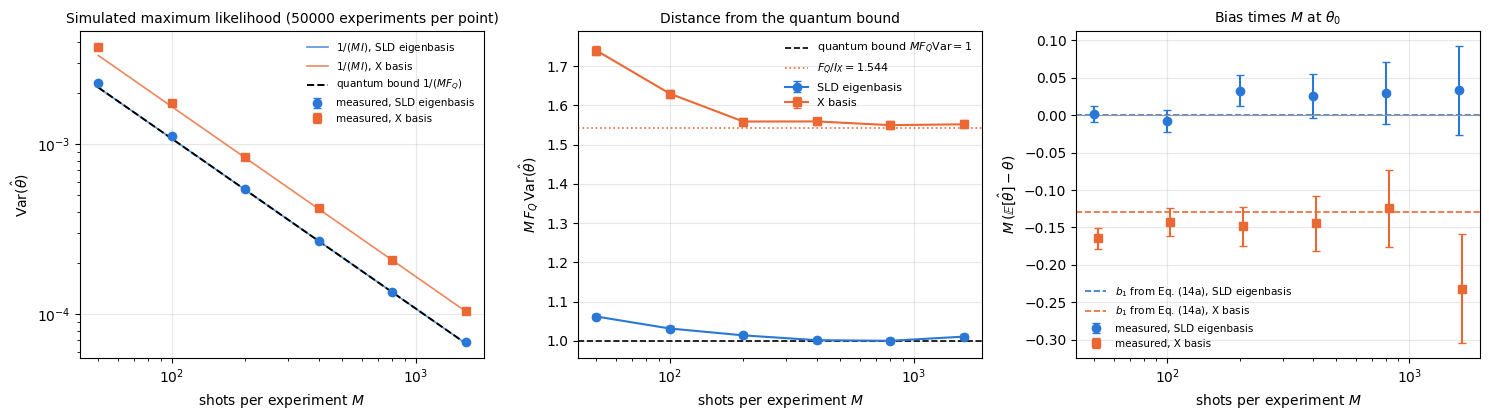

In [15]:
# ==============================================================================
# FIGURE: measured bias and variance versus the predictions
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.3))
Ms = np.array(M_SHOTS, dtype=float)
for k, (name, (I_meas, b1, rows)) in enumerate(exp_results.items()):
    bias = np.array([r[1] for r in rows]); se = np.array([r[2] for r in rows])
    v = np.array([r[3] for r in rows]); e = np.array([r[4] for r in rows])
    axes[0].errorbar(Ms, v, yerr=e, fmt=MARKERS[k], color=PALETTE[k], ms=6, capsize=3, label=f"measured, {name}")
    axes[0].plot(Ms, 1 / (Ms * I_meas), "-", color=PALETTE[k], lw=1.2, alpha=0.8,
                 label=f"$1/(M\\,I)$, {name}")
    axes[1].errorbar(Ms, v * Ms * F_Q, yerr=e * Ms * F_Q, fmt=MARKERS[k] + "-", color=PALETTE[k], ms=6,
                     capsize=3, label=name)
    axes[2].errorbar(Ms * (1 + 0.03 * k), Ms * bias, yerr=Ms * se, fmt=MARKERS[k], color=PALETTE[k], ms=6,
                     capsize=3, label=f"measured, {name}")
    axes[2].axhline(b1, color=PALETTE[k], ls="--", lw=1.2, label=f"$b_1$ from Eq. (14a), {name}")
axes[0].plot(Ms, 1 / (Ms * F_Q), "k--", lw=1.4, label=r"quantum bound $1/(M F_Q)$")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("shots per experiment $M$"); axes[0].set_ylabel(r"$\mathrm{Var}(\hat\theta)$")
axes[0].set_title(f"Simulated maximum likelihood ({R_EXP} experiments per point)", fontsize=10)
axes[0].legend(fontsize=7.5)
axes[1].axhline(1.0, color="k", ls="--", lw=1.2, label=r"quantum bound $M F_Q\mathrm{Var}=1$")
axes[1].axhline(F_Q / I_x, color=PALETTE[1], ls=":", lw=1.2, label=r"$F_Q/I_X=%.3f$" % (F_Q / I_x))
axes[1].set_xscale("log")
axes[1].set_xlabel("shots per experiment $M$"); axes[1].set_ylabel(r"$M\,F_Q\,\mathrm{Var}(\hat\theta)$")
axes[1].set_title("Distance from the quantum bound", fontsize=10); axes[1].legend(fontsize=8)
axes[2].axhline(0.0, color="0.6", lw=0.8)
axes[2].set_xscale("log")
axes[2].set_xlabel("shots per experiment $M$"); axes[2].set_ylabel(r"$M\,(\mathbb{E}[\hat\theta]-\theta)$")
axes[2].set_title(r"Bias times $M$ at $\theta_0$", fontsize=10); axes[2].legend(fontsize=7.5)
fig.tight_layout(); plt.show()

The figure and the tables contain the central claim of the chapter. Both readouts give a maximum-likelihood estimator
whose variance falls like $1/M$ and approaches *its own* classical Cramér–Rao bound $1/(M\,I)$ from above, as the
asymptotic-efficiency discussion of notebook 29 predicts. With $R=50\,000$ experiments per point ($\pm0.63\%$ on each
variance) the approach is resolved for both. In the $X$ basis $M\,I\,\mathrm{Var}=1.127,\,1.056,\,1.010$ at
$M=50,\,100,\,200$; in the SLD basis $1.062,\,1.031,\,1.014$. The excess shrinks roughly like $1/M$: times $M$ it is
about $3$ for the SLD readout at $M=50$–$200$, and $6.4$ and $5.6$ for the $X$ readout at $M=50$ and $100$ — the
$O(1/M)$ correction expected from the next order of the expansion of Section 9.3. From $M=400$ on all values lie within two error bars of $1$
(largest deviation $1.7$ error bars).

Only the SLD measurement's bound coincides with the quantum bound $1/(M F_Q)$. The middle panel plots
$M F_Q\mathrm{Var}(\hat\theta)$, which settles at $1$ for the SLD basis and at $F_Q/I_X=1.544$ for the $X$ basis
(measured $1.552\pm0.010$ at $M=1600$): the convenient readout throws away about a third of the Fisher information the
state was carrying, so it needs $54\%$ more shots for the same error bar. The asserts check both values to five error
bars, and check that the $X$ readout fails the quantum-bound test by more than fifty.

The right panel tests Eq. (14a). For the SLD readout $b_1(\theta_0)$ vanishes ($\vert b_1\vert<10^{-9}$), and the measured
bias is compatible with zero at every $M$ (at most $1.6$ standard errors). For the $X$ readout $b_1=-0.129$, and the
measured bias follows $b_1/M$ within one and a half standard errors from $M=100$ on; at $M=50$ it is $-0.00329\pm0.00027$
against $b_1/M=-0.00258$, a $2.6\sigma$ difference that is the expected size of the next, $O(M^{-2})$, term. The
hypothesis "unbiased" fails there by twelve standard errors. The bias is nevertheless irrelevant for the error budget:
its square, $b_1^2/M^2$, is at most $0.2\%$ of the variance (at $M=50$) and falls like $1/M$ relative to it.

The offset table (Step 10b) closes the loop with Section 8.2. Keeping the measurement fixed at the basis built for
$\theta_0=0.3$ and moving the *true* phase to $\theta_0\pm0.05$ and $\theta_0\pm0.15$, two things change. The bias becomes
visible and changes sign with the offset, $-0.00048\pm0.00008$ and $+0.00042\pm0.00008$ at $\theta_0\mp0.15$ against
the predicted $\mp0.00040$; $b_1$ vanishes at the design point only. And the variance grows as the *classical* bound of the fixed measurement demands: at $\theta_0\pm0.15$ the
measurement retains $I/F_Q=0.923$, so $\mathrm{Var}$ should rise by $1/0.923-1=8.3\%$; measured $7.7\%$ and $9.2\%$
(each $\pm0.9\%$), while $M\,I\,\mathrm{Var}$ stays within about two error bars of $1$ in every row (largest
deviation $2.1$). The Cramér–Rao bound that a
real experiment meets is the one belonging to the measurement it actually performed; the quantum bound is reached only
where the two coincide.

> **Physics insight.** $F_Q$ converts directly into a shot budget: doubling it halves the number of repetitions needed for
> a given error bar. The rest of this chapter is an attempt to (i) prepare a state with a large $F_Q$ and (ii) find a
> readout whose classical Fisher information gets close to it. The second half does not follow from the first.

## 10. The zoo: states, noise and generators

With a validated machine we can now run it over the cases the rest of the chapter needs.

### 10.1 Choice of generator

The same state can be an excellent or a useless probe depending on what it is asked to sense. We tabulate $F_Q$ for five
generators: the three collective components $J_x,J_y,J_z$, a staggered field $\tfrac12\sum_q(-1)^qZ_q$ (which senses an
alternating field but is blind to a uniform one), and a single-site $\tfrac12Z_0$ (a local probe).

In [16]:
# ==============================================================================
# STEP 11: F_Q for five generators across the state zoo
# ==============================================================================
N_G = 4
gen_table = {"J_x": gen_collective(N_G, X), "J_y": gen_collective(N_G, Y), "J_z": gen_collective(N_G, Z),
             "staggered Z": gen_staggered(N_G, Z), "single site Z_0": gen_single_site(N_G, 0, Z)}
state_table = {"product |+>^N": to_dm(product_state("+" * N_G)), "GHZ": to_dm(ghz_state(N_G)),
               "W": to_dm(w_state(N_G)), "Dicke N/2": to_dm(dicke_state(N_G, N_G // 2)),
               "Haar random": to_dm(haar_state(jax.random.PRNGKey(7), N_G)),
               "GHZ, dephased 0.1": local_channel(to_dm(ghz_state(N_G)), kraus_dephasing(0.1)),
               "maximally mixed": maximally_mixed(N_G)}
print(f"N = {N_G}   (SQL: F_Q = {N_G} for collective generators;  Heisenberg: {N_G ** 2})\n")
print(f"{'state':>20s} |" + "".join(f"{g:>16s}" for g in gen_table))
for sname, rho in state_table.items():
    vals = [float(qfi_unitary(rho, g)) for g in gen_table.values()]
    print(f"{sname:>20s} |" + "".join(f"{v:16.4f}" for v in vals))

N = 4   (SQL: F_Q = 4 for collective generators;  Heisenberg: 16)

               state |             J_x             J_y             J_z     staggered Z single site Z_0
       product |+>^N |          0.0000          4.0000          4.0000          4.0000          1.0000
                 GHZ |          4.0000          4.0000         16.0000          0.0000          1.0000
                   W |         10.0000         10.0000          0.0000          4.0000          0.7500
           Dicke N/2 |         12.0000         12.0000          0.0000          5.3333          1.0000
         Haar random |          2.3907          2.9828          4.1898          3.9417          0.8712
   GHZ, dephased 0.1 |          4.0000          4.0000          2.6844          0.0000          0.1678
     maximally mixed |          0.0000          0.0000          0.0000          0.0000          0.0000


Read across the rows and down the columns.

* **GHZ** attains the Heisenberg value for $J_z$ ($F_Q=N^2=16$) and is mediocre for everything else — including the staggered field, where
  it scores exactly $0$: with $N$ even, $\tfrac12\sum_q(-1)^qZ_q$ annihilates both $\vert0\cdots0\rangle$ and
  $\vert1\cdots1\rangle$, so the generator does not move the state at all.
* **W** and **Dicke** are blind to $J_z$ (they are its eigenstates) and useful for the transverse components.
* The **single-site** generator $G=\tfrac12Z_0$ never exceeds $1$: a local probe on one qubit cannot beat the
  single-qubit limit, no matter how entangled the rest of the register is. For a pure global state the value is exactly
  $F_Q=4\mathrm{Var}(\tfrac12Z_0)=1-\langle Z_0\rangle^2$ — hence $1$ for the unpolarised cases (product
  $\vert+\rangle^{\otimes N}$, GHZ, Dicke), $1-(1/2)^2=0.75$ for the W state, whose qubits carry
  $\langle Z_0\rangle=1-2/N=1/2$, and $0.87$ for the random state. For the *mixed* dephased GHZ it drops to $0.17$,
  far below the pure-state formula, exactly as Section 6 warned.
* The **maximally mixed state** scores exactly $0$ for every generator — it is invariant under every unitary, so nothing is
  encoded. It is also the sharpest illustration of the gap formula of Section 6: the maximally mixed state has
  $4\,\mathrm{Var}(J_z)=N$, the standard-quantum-limit value, made entirely of classical fluctuations, and zero quantum
  Fisher information.

### 10.2 Noise before and after the encoding

If the noise channel $\mathcal{E}$ acts *before* the phase is imprinted, the
final state is $U\,\mathcal{E}(\rho)\,U^\dagger$; if *after*, it is $\mathcal{E}\!\left(U\rho U^\dagger\right)$. These are
equal for all $\rho$ precisely when the channel is **covariant** with respect to the encoding group,

$$\mathcal{E}\!\left(U\rho U^\dagger\right)=U\,\mathcal{E}(\rho)\,U^\dagger\qquad\text{for all }\theta . \tag{15}$$

Three predictions we can make before running anything:

* **Depolarising** is covariant under *every* unitary: $\mathcal{E}(\rho)=(1-\tfrac{4p}{3})\rho+\tfrac{4p}{3}\tfrac{\mathbb 1}{2}\mathrm{Tr}\rho$,
  and both terms manifestly commute with conjugation by $U$. So the order never matters.
* **Dephasing** has Kraus operators $\{\sqrt{1-p}\,\mathbb 1,\sqrt p\,Z\}$, which commute with $e^{-i\theta Z/2}$ — so it
  is covariant under a $J_z$ encoding, but not under $J_x$.
* **Amplitude damping** has $K_0=\mathrm{diag}(1,\sqrt{1-g})$, which is diagonal and commutes with $e^{-i\theta Z/2}$, and
  $K_1=\sqrt g\,\vert0\rangle\langle1\vert$, for which $UK_1U^\dagger=e^{-i\theta}K_1$ — a global phase that cancels in
  $K_1\rho K_1^\dagger$. So amplitude damping is *also* covariant under $J_z$, though not under $J_x$.

In [17]:
# ==============================================================================
# STEP 12: noise before vs after the encoding
# ==============================================================================
N_O = 4
THETA_O = 0.7
CH = {"depolarising p=0.1": kraus_depolarizing(0.1), "dephasing p=0.1": kraus_dephasing(0.1),
      "amp. damping g=0.1": kraus_amplitude_damping(0.1)}
print(f"GHZ_{N_O}, theta = {THETA_O};  F_Q is theta-independent, so a difference means the two STATES differ\n")
print(f"{'generator':>10s} {'channel':>22s} | {'F_Q (noise before)':>19s} {'F_Q (noise after)':>18s} "
      f"{'|difference|':>13s} {'commute?':>9s}")
for gname, P in (("J_z", Z), ("J_x", X)):
    gen = gen_collective(N_O, P)
    for cname, K in CH.items():
        rho_ghz = to_dm(ghz_state(N_O))
        rho_before = encode_dm(local_channel(rho_ghz, K), gen, THETA_O)      # noise, then encode
        rho_after = local_channel(encode_dm(rho_ghz, gen, THETA_O), K)       # encode, then noise
        f_b, f_a = float(qfi_unitary(rho_before, gen)), float(qfi_unitary(rho_after, gen))
        d_states = max_abs(dm_matrix(rho_before) - dm_matrix(rho_after))
        print(f"{gname:>10s} {cname:>22s} | {f_b:19.6f} {f_a:18.6f} {abs(f_b - f_a):13.2e} "
              f"{'YES' if d_states < 1e3 * TOL else 'no':>9s}")
    print()

GHZ_4, theta = 0.7;  F_Q is theta-independent, so a difference means the two STATES differ

 generator                channel |  F_Q (noise before)  F_Q (noise after)  |difference|  commute?
       J_z     depolarising p=0.1 |            6.710862           6.710862      1.07e-14       YES
       J_z        dephasing p=0.1 |            2.684355           2.684355      1.78e-15       YES
       J_z     amp. damping g=0.1 |           12.676730          12.676730      1.78e-14       YES

       J_x     depolarising p=0.1 |            2.915444           2.915444      1.78e-15       YES
       J_x        dephasing p=0.1 |            4.000000           3.787731      2.12e-01        no
       J_x     amp. damping g=0.1 |            3.579653           3.604493      2.48e-02        no



The measured table matches all three predictions. For $G=J_z$ all three channels commute with the encoding, so the two
orderings give literally the same density matrix (the difference is at machine precision, $10^{-14}$) and therefore the
same $F_Q$. For $G=J_x$ only the depolarising channel still commutes; dephasing and amplitude damping do not, and the
resulting $F_Q$ values genuinely differ — and *which order is better depends on the channel*: with dephasing the
noise-first state is the better probe ($4.000$ against $3.788$), with amplitude damping the noise-last one is
($3.604$ against $3.580$). There is no universal rule, only the covariance criterion of Eq. (15) telling you whether
the question has an answer at all.

The entry $4.000$ is not a rounded number: **local dephasing does not degrade the $J_x$ sensitivity of a GHZ state at
all**, at any strength, for $N\ge3$. Dephasing leaves the state inside the two-dimensional span of
$\vert\mathrm{GHZ}_\pm\rangle=(\vert0\cdots0\rangle\pm\vert1\cdots1\rangle)/\sqrt2$, with eigenvalues
$\lambda_\pm=(1\pm(1-2p)^N)/2$. A single spin flip takes either of them out of that span, so
$\langle\mathrm{GHZ}_+\vert J_x\vert\mathrm{GHZ}_-\rangle=0$ and the only surviving terms of Eq. (12) are the
support–kernel ones, which give $F_Q=4\sum_\pm\lambda_\pm\langle\mathrm{GHZ}_\pm\vert J_x^2\vert\mathrm{GHZ}_\pm\rangle
=4\cdot\tfrac N4=N$ independently of $p$. The value $\langle\mathrm{GHZ}_\pm\vert J_x^2\vert\mathrm{GHZ}_\pm\rangle=N/4$ uses
$N\ge3$: for $N=2$ the two-flip term $X_1X_2$ connects $\vert00\rangle$ and $\vert11\rangle$, and $F_Q(J_x)$ does decay with
$p$ ($4,\,3.62,\,3.28,\,2.50$ at $p=0,\,0.05,\,0.1,\,0.25$). (Checked: $F_Q(J_x)=N$ to ten digits for $N=3,4,5,6$
and $p=0,0.05,0.1,0.25,0.5$, while $F_Q(J_z)$ collapses from $16$ to $0$ over the same range.) The lesson is that "noise"
is never bad in the abstract — it is bad for the particular coherence the particular generator relies on.

> **Physics insight.** This is why the noise model in a metrology paper always specifies *when* the noise acts. In a real
> interferometer the noise acts *during* the encoding, continuously, which is neither "before" nor "after" — that case
> belongs to the Lindblad machinery of
> [16 — Lindblad master equation](../ch06_open_quantum_systems/16_lindblad_master_equation.ipynb), and it is what sets the
> *optimal interrogation time* discussed in notebook 31.

### 10.3 Imperfect preparation: the cat doublet of the Ising chain

In the ferromagnetic phase a finite transverse-field Ising chain has two lowest eigenstates $\vert E_0\rangle$ and
$\vert E_1\rangle$ that are almost degenerate: the symmetric and the antisymmetric superposition of the two
ferromagnetic configurations, two "cat" states of opposite spin-flip parity $P=\prod_qX_q$. The ground state is a
Heisenberg-type probe for $J_z$ (notebook 29 measured its $F_Q$). A preparation that is not perfect — for instance one
exposed to a stray field that breaks the spin-flip symmetry — leaves some weight $q$ in the partner state $\vert E_1\rangle$, and
unless the relative phase between the two components is controlled, the state that the experiment actually holds is the
incoherent mixture

$$\rho_q=(1-q)\,\vert E_0\rangle\langle E_0\vert+q\,\vert E_1\rangle\langle E_1\vert ,\qquad 0\le q\le\tfrac12 . \tag{16}$$

Eq. (12) evaluates $F_Q[\rho_q]$ in closed form. The eigenvalues are $\lambda_0=1-q$, $\lambda_1=q$ and zero on the rest
of the spectrum; write $G_{mn}=\langle E_m\vert G\vert E_n\rangle$. Three kinds of pairs contribute:

* the pair $(0,1)$ and $(1,0)$: $2\cdot2\,\frac{(1-2q)^2}{1}\,\vert G_{01}\vert^2$;
* the pairs $(0,k)$ and $(k,0)$ with $k\ge2$ (support–kernel terms): $2\cdot2\,\frac{(1-q)^2}{1-q}\,\vert G_{0k}\vert^2=4(1-q)\vert G_{0k}\vert^2$;
* likewise $4q\,\vert G_{1k}\vert^2$ for the pairs $(1,k)$ and $(k,1)$.

For $G=J_z$ parity decides everything: $PJ_zP=-J_z$, so the diagonal elements $\langle E_i\vert J_z\vert E_i\rangle$
vanish, and $\sum_{k\ge2}\vert G_{0k}\vert^2=\langle E_0\vert J_z^2\vert E_0\rangle-\vert G_{01}\vert^2$. With
$F_i=4\,\mathrm{Var}_{E_i}(J_z)$ the pure-state values and $C=4\vert G_{01}\vert^2$ the part carried by the coherence
between the two cats,

$$F_Q^{(J_z)}(q)=(1-2q)^2\,C+(1-q)\,(F_0-C)+q\,(F_1-C). \tag{17}$$

If the ground state's sensitivity comes almost entirely from the cat coherence, $C\approx F_0$, then Eq. (17) reduces to
the **two-level model** $F_Q^{(J_z)}\approx(1-2q)^2F_0$: an admixture $q$ costs a factor $(1-2q)^2$, and at $q=\tfrac12$
nothing is left. For $G=J_x$ the situation is the opposite: $PJ_xP=+J_x$ cannot connect states of opposite parity,
$G_{01}=0$, and the same bookkeeping gives the straight line

$$F_Q^{(J_x)}(q)=(1-q)\,F_0^{(x)}+q\,F_1^{(x)} , \tag{18}$$

the saturated-convexity case of Section 7.2 (orthogonal supports that the generator does not connect).

In [18]:
# ==============================================================================
# STEP 13: QFI of the incoherently mixed cat doublet of the transverse-field Ising chain
# ==============================================================================
N_T, H_FIELD = 5, 0.5
terms_T = heisenberg_terms(N_T, Jxx=0.0, Jyy=0.0, Jzz=-1.0, hx=-H_FIELD)      # H = -sum ZZ - h sum X
H_dense = dense_hamiltonian(terms_T, N_T)                                     # validation-size dense matrix (32 x 32)
evals, evecs = jnp.linalg.eigh(H_dense)
gap = float(evals[1] - evals[0])                                              # splitting of the cat doublet
gap_2 = float(evals[2] - evals[0])                                            # distance to the rest of the spectrum
psi0 = evecs[:, 0].reshape((2,) * N_T)                                        # |E_0>, symmetric cat
psi1 = evecs[:, 1].reshape((2,) * N_T)                                        # |E_1>, antisymmetric cat
Q_MIX = np.array([0.0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5])            # weight of the partner state


def doublet_mixture(q):
    """rho_q = (1-q)|E_0><E_0| + q|E_1><E_1|, Eq. (16), as a density TENSOR (small N only)."""
    mat = (1.0 - q) * jnp.outer(evecs[:, 0], evecs[:, 0].conj()) + q * jnp.outer(evecs[:, 1], evecs[:, 1].conj())
    return dm_tensor(mat, N_T)


# ingredients of Eqs. (17) and (18): pure-state values and the coherence term C = 4 |<E_0|J_z|E_1>|^2
f0_z, f1_z = float(qfi_pure(psi0, Z)), float(qfi_pure(psi1, Z))
f0_x, f1_x = float(qfi_pure(psi0, X)), float(qfi_pure(psi1, X))
Jz_psi1 = apply_collective(psi1, Z) / 2.0                                     # J_z |E_1>  (apply_collective gives sum_q Z_q)
C_coh = 4.0 * float(jnp.abs(jnp.vdot(psi0, Jz_psi1)) ** 2)
print(f"transverse-field Ising, N = {N_T}, h = {H_FIELD}:  E_0 = {float(evals[0]):.6f}, "
      f"doublet splitting = {gap:.6f}, gap to E_2 = {gap_2:.4f}")
print(f"F_Q(J_z): E_0 {f0_z:.4f} (= {f0_z / N_T ** 2:.3f} N^2), E_1 {f1_z:.4f};  coherence part C = {C_coh:.4f}")
print(f"F_Q(J_x): E_0 {f0_x:.4f}, E_1 {f1_x:.4f}\n")

print(f"{'q':>6s} {'purity':>8s} | {'F_Q(J_z)':>10s} {'Eq. (17)':>10s} {'(1-2q)^2 F_0':>13s} | "
      f"{'F_Q(J_x)':>10s} {'Eq. (18)':>10s}")
mix = []
for q in Q_MIX:
    rho_q = doublet_mixture(float(q))
    fz = float(qfi_unitary(rho_q, gen_collective(N_T, Z)))
    fx = float(qfi_unitary(rho_q, gen_collective(N_T, X)))
    eq17 = (1 - 2 * q) ** 2 * C_coh + (1 - q) * (f0_z - C_coh) + q * (f1_z - C_coh)
    eq18 = (1 - q) * f0_x + q * f1_x
    model = (1 - 2 * q) ** 2 * f0_z
    mix.append((q, float(purity(dm_matrix(rho_q))), fz, fx, eq17, model))
    print(f"{q:6.2f} {mix[-1][1]:8.4f} | {fz:10.4f} {eq17:10.4f} {model:13.4f} | {fx:10.4f} {eq18:10.4f}")
    # Eqs. (17) and (18) are exact: they must agree with the SLD computation to numerical precision
    assert abs(fz - eq17) < 1e4 * TOL * N_T ** 2 and abs(fx - eq18) < 1e4 * TOL * N_T ** 2, (q, fz, eq17, fx, eq18)
    # the two-level model is an approximation, accurate to a few per cent of F_0 because C is close to F_0
    assert abs(fz - model) < 0.05 * f0_z, (q, fz, model)

transverse-field Ising, N = 5, h = 0.5:  E_0 = -4.469490, doublet splitting = 0.047037, gap to E_2 = 1.4171
F_Q(J_z): E_0 21.4723 (= 0.859 N^2), E_1 22.6032;  coherence part C = 21.0997
F_Q(J_x): E_0 5.6518, E_1 3.9675

     q   purity |   F_Q(J_z)   Eq. (17)  (1-2q)^2 F_0 |   F_Q(J_x)   Eq. (18)


  0.00   1.0000 |    21.4723    21.4723       21.4723 |     5.6518     5.6518
  0.01   0.9802 |    20.6481    20.6481       20.6220 |     5.6350     5.6350
  0.02   0.9608 |    19.8407    19.8407       19.7889 |     5.6182     5.6182
  0.05   0.9050 |    17.5199    17.5199       17.3926 |     5.5676     5.5676
  0.10   0.8200 |    13.9895    13.9895       13.7423 |     5.4834     5.4834
  0.20   0.6800 |     8.1947     8.1947        7.7300 |     5.3150     5.3150
  0.30   0.5800 |     4.0878     4.0878        3.4356 |     5.1465     5.1465
  0.40   0.5200 |     1.6690     1.6690        0.8589 |     4.9781     4.9781
  0.50   0.5000 |     0.9381     0.9381        0.0000 |     4.8097     4.8097


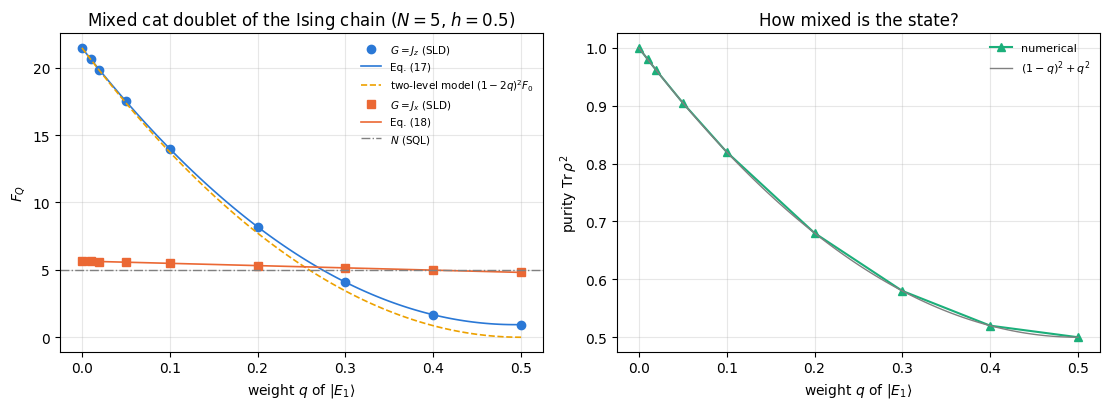

In [19]:
# ==============================================================================
# FIGURE: an incoherent admixture of the partner cat destroys the J_z resource
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.2))
qs = np.array([r[0] for r in mix])
q_fine = np.linspace(0.0, 0.5, 101)
axes[0].plot(qs, [r[2] for r in mix], "o", color=PALETTE[0], label=r"$G=J_z$ (SLD)")
axes[0].plot(q_fine, (1 - 2 * q_fine) ** 2 * C_coh + (1 - q_fine) * (f0_z - C_coh) + q_fine * (f1_z - C_coh),
             "-", color=PALETTE[0], lw=1.2, label="Eq. (17)")
axes[0].plot(q_fine, (1 - 2 * q_fine) ** 2 * f0_z, "--", color=PALETTE[3], lw=1.2,
             label=r"two-level model $(1-2q)^2F_0$")
axes[0].plot(qs, [r[3] for r in mix], "s", color=PALETTE[1], label=r"$G=J_x$ (SLD)")
axes[0].plot(q_fine, (1 - q_fine) * f0_x + q_fine * f1_x, "-", color=PALETTE[1], lw=1.2, label="Eq. (18)")
axes[0].axhline(N_T, color="0.5", ls="-.", lw=1, label=r"$N$ (SQL)")
axes[0].set_xlabel(r"weight $q$ of $\vert E_1\rangle$"); axes[0].set_ylabel(r"$F_Q$")
axes[0].set_title(f"Mixed cat doublet of the Ising chain ($N={N_T}$, $h={H_FIELD}$)"); axes[0].legend(fontsize=7.5)

axes[1].plot(qs, [r[1] for r in mix], "^-", color=PALETTE[2], label="numerical")
axes[1].plot(q_fine, (1 - q_fine) ** 2 + q_fine ** 2, "-", color="0.5", lw=1, label=r"$(1-q)^2+q^2$")
axes[1].set_xlabel(r"weight $q$ of $\vert E_1\rangle$"); axes[1].set_ylabel(r"purity $\mathrm{Tr}\,\rho^2$")
axes[1].set_title("How mixed is the state?"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

The SLD values and the closed forms agree in every row to the printed four digits, for both generators (the assert
enforces Eqs. (17) and (18) at numerical precision). The level structure explains the rest. The two cats are split by
only $0.047$, against a gap of $1.42$ to $\vert E_2\rangle$, and the ground state's $F_Q(J_z)=21.47$ is carried almost
entirely by the coherence between them: $C=21.10$, i.e. $98\%$ of $F_0$. The two-level model $(1-2q)^2F_0$ therefore
tracks the exact curve, with a largest deviation of $0.94$ at $q=\tfrac12$ — the leakage terms
$\tfrac12(F_0-C)+\tfrac12(F_1-C)$ that survive when the cat coherence is gone.

An admixture of $q=0.1$ already costs a third of the sensitivity ($13.99$ out of $21.47$), and between
$q=0.2$ and $q=0.3$ the state drops below the standard quantum limit $N=5$ ($4.09$ at $q=0.3$), although its purity
is still $0.58$. At $q=\tfrac12$, purity $\tfrac12$, only $0.94$ is left.

$F_Q(J_x)$ does not use the cat coherence at all. It moves along the straight line of Eq. (18) from $5.65$ (the value of
$\vert E_0\rangle$) to $4.81$ at $q=\tfrac12$, the average of the two pure-state values $5.65$ and $3.97$ — the
saturated-convexity case of Section 7.2, now produced by a symmetry rather than by construction.

> **Physics insight.** This is the mixed-state counterpart of the fragility we saw for dephasing in notebook 29. A
> Heisenberg-scaling resource built on a macroscopic superposition keeps only the fraction $(1-2q)^2$ of its sensitivity,
> a loss of $4q$ already at small admixture $q$ of the parity partner, and the partner is only $\Delta=0.047$ away in
> energy here: any symmetry-breaking perturbation
> whose matrix element between the two cats is comparable to that splitting mixes them. It is one more reason why
> practical quantum metrology aims at squeezed and Dicke-type states rather than at cats.

## 11. Cost, and where the wall is

| step | algorithm | cost | memory |
|---|---|---|---|
| encoding, Eq. (4) | $2N$ single-qubit einsums on a rank-$2N$ tensor | $O(N4^N)$ | $O(4^N)$ |
| derivative, Eq. (5) | $2N$ einsums | $O(N4^N)$ | $O(4^N)$ |
| SLD + $F_Q$, Eqs. (8), (11) | one Hermitian `eigh` of a $2^N\times2^N$ matrix | $O(8^N)$ | $O(4^N)$ |
| optimal measurement | a second `eigh`, of $L$ | $O(8^N)$ | $O(4^N)$ |
| pure state, $4\mathrm{Var}(G)$ | matrix-free, notebook 29 | $O(N2^N)$ | $O(2^N)$ |

The eigendecomposition dominates and it is the reason this notebook stops at $N\le6$ or $7$. We measure it.

  N  dim 2^N  rho entries |  encode [ms]  drho [ms]  SLD+F_Q [ms]  x prev N  (compile [s]) |  pure 4Var [ms]


  2        4           16 |        0.015      0.012         0.020         -           0.10 |           0.011


  3        8           64 |        0.021      0.021         0.035      1.71           0.10 |           0.010


  4       16          256 |        0.024      0.023         0.036      1.03           0.11 |           0.011


  5       32         1024 |        0.046      0.047         0.124      3.45           0.14 |           0.011


  6       64         4096 |        0.194      0.157         0.733      5.94           0.19 |           0.024


  7      128        16384 |        0.807      0.595         2.723      3.71           0.33 |           0.024


  8      256        65536 |        1.438      1.496        13.780      5.06           0.20 |           0.027


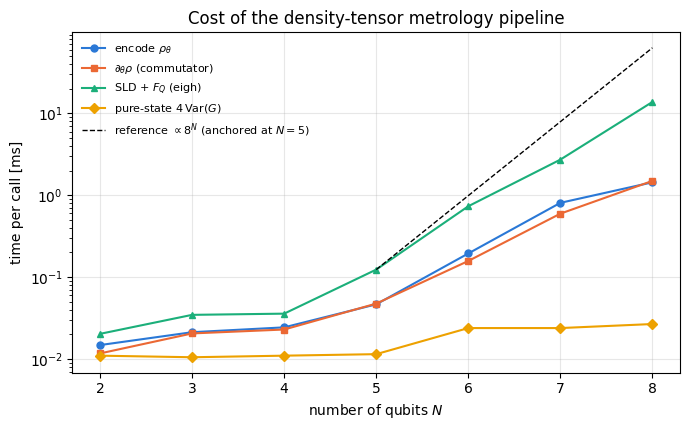

In [20]:
# ==============================================================================
# STEP 14: measured cost of the SLD route, and the pure-state shortcut for comparison
# ==============================================================================
def timed(f, *args, budget=0.3, min_reps=5, max_reps=500):
    """(result, compile time, BEST run time).

    The first call includes tracing and compilation; the rest do not. JAX is asynchronous, so every result
    must be forced with `block_until_ready` -- otherwise one times the dispatch, not the work. We repeat for
    a fixed time `budget` and report the MINIMUM: on a shared machine the mean measures the operating
    system, the minimum measures the code.
    """
    t0 = time.time()
    out = jax.block_until_ready(f(*args))
    t_compile = time.time() - t0
    best, n, t_start = np.inf, 0, time.time()
    while n < min_reps or (time.time() - t_start < budget and n < max_reps):
        t0 = time.time()
        out = jax.block_until_ready(f(*args))
        best = min(best, time.time() - t0)
        n += 1
    return out, t_compile, best


print(f"{'N':>3s} {'dim 2^N':>8s} {'rho entries':>12s} | {'encode [ms]':>12s} {'drho [ms]':>10s} "
      f"{'SLD+F_Q [ms]':>13s} {'x prev N':>9s} {'(compile [s])':>14s} | {'pure 4Var [ms]':>15s}")
cost_rows = []
for N in (2, 3, 4, 5, 6, 7, 8):
    gen = gen_collective(N, Z)
    rho = local_channel(to_dm(ghz_state(N)), kraus_dephasing(0.05))
    _, _, t_enc = timed(jax.jit(partial(encode_dm, gen=gen, theta=0.3)), rho)
    _, _, t_der = timed(jax.jit(partial(drho_commutator, gen=gen)), rho)
    _, t_qfi_compile, t_qfi = timed(jax.jit(partial(qfi_unitary, gen=gen)), rho)
    _, _, t_pure = timed(jax.jit(lambda p: qfi_pure(p, Z)), ghz_state(N))
    ratio = f"{t_qfi / cost_rows[-1][3]:9.2f}" if cost_rows else f"{'-':>9s}"   # growth of the eigh step
    cost_rows.append((N, t_enc, t_der, t_qfi, t_pure))
    print(f"{N:3d} {2 ** N:8d} {4 ** N:12d} | {t_enc * 1e3:12.3f} {t_der * 1e3:10.3f} {t_qfi * 1e3:13.3f} "
          f"{ratio} {t_qfi_compile:14.2f} | {t_pure * 1e3:15.3f}")

fig, ax = plt.subplots(figsize=(7.0, 4.4))
Ns = np.array([r[0] for r in cost_rows], dtype=float)
for k, (lab, col) in enumerate((("encode $\\rho_\\theta$", 1), (r"$\partial_\theta\rho$ (commutator)", 2),
                                (r"SLD + $F_Q$ (eigh)", 3), (r"pure-state $4\,\mathrm{Var}(G)$", 4))):
    ax.semilogy(Ns, [r[col] * 1e3 for r in cost_rows], MARKERS[k] + "-", color=PALETTE[k], ms=5, label=lab)
ref = cost_rows[3][3] * 1e3 * 8.0 ** (Ns - Ns[3])            # anchored at N = 5, where the growth sets in
ax.semilogy(Ns[3:], ref[3:], "k--", lw=1, label=r"reference $\propto 8^N$ (anchored at $N=5$)")
ax.set_xlabel("number of qubits $N$"); ax.set_ylabel("time per call [ms]"); ax.set_xticks(Ns)
ax.set_title("Cost of the density-tensor metrology pipeline")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

The SLD step (eigendecomposition plus four matrix products) is the most expensive of the three at every size, as
predicted. Its growth with $N$ shows two regimes. Up to $N=4$ the call takes a few tens of microseconds and grows by
small, erratic factors (between $1$ and $2.5$ in our builds): it is dominated by the fixed cost of dispatching a compiled program, a few tens of microseconds, and the arithmetic is
invisible. From $N=5$ on the arithmetic dominates and the time grows by about two orders of magnitude between $N=5$
and $N=8$, an average factor of roughly $5$ per added qubit — between the $4^N$ of the matrix size and the $8^N$ of the
asymptotic cost. The individual ratios scatter between about $2$ and $7$: at these sizes LAPACK's blocked eigensolver
is not yet in its asymptotic regime, and sub-millisecond timings move with machine load from one build to the next.
The dashed $8^N$ reference is therefore anchored at $N=5$ and is meant as an upper guide for the slope, not a fit; an
anchor at $N=2$ would compare a dispatch-bound call with an arithmetic-bound eigensolver. Compilation (the extra
column, in seconds) costs $0.06$–$0.4$ s per size, thousands of calls' worth at small $N$, and is excluded from the
timings. The pure-state shortcut of notebook 29 stays essentially flat over this range: it never leaves the
state-vector representation.

**What to do when $N$ is larger.** Three escapes:

* if the state stays **pure**, use $F_Q=4\,\mathrm{Var}(G)$ — $O(N2^N)$, good to $N\approx20$;
* if the state is mixed only because a **few qubits were traced out**, use the Schmidt/QR compression of notebook 29,
  Section 15: the rank of the reduced state is bounded by the dimension of what was removed;
* if the state is genuinely mixed by noise, either restrict to the **symmetric subspace** (dimension $N+1$ instead of
  $2^N$, legitimate whenever state, noise and generator are permutation-invariant; Exercise 7 below) or build the
  density matrix from **quantum-trajectory** samples and evaluate $F_Q$ on the averaged state (an exercise of
  notebook 34).

## 12. Key takeaways

* **The pipeline.** Prepare $\rho$, encode $\rho_\theta=e^{-i\theta G}\rho e^{+i\theta G}$, measure, estimate. For a
  generator that is a sum of commuting single-qubit terms the encoding factorises into $N$ local gates, Eq. (4), and the
  derivative is the commutator $\partial_\theta\rho=-i[G,\rho_\theta]$, Eq. (5) — which we verified against finite
  differences and against `jax.jacfwd` pushed through the whole simulation.
* **The SLD.** $\partial_\theta\rho=\tfrac12(L\rho+\rho L)$ is a Lyapunov equation; in the eigenbasis of $\rho$ it
  decouples into $L_{mn}=2(\partial\rho)_{mn}/(\lambda_m+\lambda_n)$. Where $\lambda_m+\lambda_n=0$ the equation is a
  *consistency condition* ($(\partial\rho)_{mn}=0$, which holds) and $L_{mn}$ is free — and irrelevant, because it is
  multiplied by $\lambda_m=0$ in $F_Q$. In code: a double `jnp.where`, never a bare division. This is safe as long as
  the *rank of $\rho_\theta$ does not change with $\theta$*, which unitary encoding guarantees; where it does change,
  $F_Q$ is discontinuous and the bound built from it can be unattainable.
* **The QFI.** $F_Q=\mathrm{Tr}(\rho L^2)=2\sum_{mn}\vert(\partial\rho)_{mn}\vert^2/(\lambda_m+\lambda_n)$, which for
  unitary encoding becomes $2\sum_{mn}(\lambda_m-\lambda_n)^2/(\lambda_m+\lambda_n)\vert G_{mn}\vert^2$ and for pure
  states reduces to $4\,\mathrm{Var}(G)$. It is $\theta$-independent, convex, and never larger than
  $4\,\mathrm{Var}(G)$ — using the variance formula on a mixed state over-reports the QFI, by $40\%$ for a half-mixed
  GHZ state and by a factor of sixty for a strongly dephased one.
* **Validation ladder.** $\mathrm{Tr}(\rho L^2)$ vs the explicit double sum vs the engine's `qfi_mixed` vs
  $4\mathrm{Var}(G)$ on pure states vs the Bures fidelity susceptibility $8(1-\sqrt F)/d\theta^2$, whose error shows the
  textbook V between $O(d\theta^2)$ truncation and $O(d\theta^{-2})$ round-off with an optimum near $d\theta\approx10^{-4}$.
* **The optimal measurement** is the projective measurement in the eigenbasis of $L$; the proof that it saturates the
  bound is two lines once $L$ exists, and the proof that nothing beats it is Cauchy–Schwarz in the Hilbert–Schmidt inner
  product. It is only *locally* optimal: its Fisher information equals $F_Q$ at the $\theta$ it was designed for and at
  the periodic revivals $\theta_0+k\pi/N$, and falls to zero half-way between.
* **Simulated experiments confirm all of it.** Maximum likelihood on sampled counts (the sufficient statistic,
  validated against click-by-click sampling) approaches $\mathrm{Var}(\hat\theta)=1/(M\,I)$ from above, with an excess
  of $6$–$13\%$ at $M=50$ that falls roughly like $1/M$; its bias follows the first-order law $b_1/M$ of Eq. (14a),
  zero at the design point of the SLD readout. Resolving these effects needs $R=50\,000$ experiments per point and an
  independent PRNG key per row. Only the SLD readout has $I=F_Q$, while
  the convenient $X$-basis readout keeps $65\%$ of the Fisher information and therefore needs $54\%$ more shots for the
  same error bar on this noisy GHZ state.
* **Physics learned along the way.** Noise commutes with the encoding exactly when the channel is covariant under it
  (depolarising always; dephasing and amplitude damping under $J_z$ but not under $J_x$) — and when it does not, which
  order is better depends on the channel. Local dephasing destroys $F_Q(J_z)$ of a GHZ state but leaves $F_Q(J_x)=N$
  untouched at any strength ($N\ge3$). A single-site generator gives $F_Q\le1$ however entangled the state
  ($F_Q=1-\langle Z_0\rangle^2$ for pure states). The maximally mixed state has $4\,\mathrm{Var}(J_z)=N$, the SQL value,
  and zero QFI. And a cat ground
  state with an incoherent admixture $q$ of its parity partner keeps only $\approx(1-2q)^2$ of its $J_z$ sensitivity,
  Eq. (17), while its $J_x$ sensitivity interpolates linearly, Eq. (18).
* **Cost.** $O(8^N)$ from the eigendecomposition asymptotically — at $N\le8$ the measured growth is about a factor $5$
  per qubit, between $4^N$ and $8^N$ — hence $N\le6$–$7$ for full density tensors; escape routes are purity,
  Schmidt compression, permutation symmetry, or trajectories.

## 13. Exercises

1. ★ **Read the SLD.** For a single qubit in the state $\rho=\tfrac12(\mathbb 1+r\,Z)$ with $G=\tfrac12 X$, solve Eq. (7)
   by hand and show that $F_Q=r^2$. Check it with `qfi_unitary` for $r=0,0.3,\dots,1$, and explain why the answer is $1$
   (the pure-state value) only at $r=1$.
2. ★ **The other form of the QFI.** Section 5.4 claims $F_Q=\mathrm{Tr}(L\,\partial_\theta\rho)$ as well as
   $\mathrm{Tr}(\rho L^2)$. Prove the identity from Eq. (6), then verify it numerically on three of the mixed states of
   Step 5.
3. ★★ **Sub-optimal readouts (extend the code).** Add the $Y$ basis and the "parity after a $\pi/2$ pulse about
   $\mathbf n$" family of measurements to Step 8, and scan the pulse axis $\mathbf n$ over a great circle to find the best
   *single-qubit-rotation plus $Z$ readout*. How close to $F_Q$ can such a simple measurement get for the damped GHZ state,
   and for the dephased one?
4. ★★ **Adaptive estimation (extend the code).** Section 8 showed that the optimal basis depends on $\theta$. Implement a
   two-stage protocol: spend $M/10$ shots in the $X$ basis to get a rough $\hat\theta_1$, rebuild the SLD basis at
   $\hat\theta_1$, and spend the remaining $9M/10$ there. Does the total variance approach $1/(MF_Q)$? Compare with
   spending all $M$ shots in the $X$ basis.
5. ★★ **Convexity saturated.** Section 7.2 explained why mixing GHZ with W is exactly linear for $G=J_z$. Predict, then
   check numerically, what happens for $G=J_x$, and construct a third pair of states for which convexity is again
   saturated.
6. ★★ **Noise during the encoding (physics).** Replace "before" and "after" by "throughout": split the encoding into $K$
   steps of $\theta/K$ and apply a channel of strength $p_K$ after each, with $p_K$ chosen so that the $K$ channels compose
   to the channel of strength $p$ (for dephasing, $(1-2p_K)^K=1-2p$; a naive $p/K$ composes to $e^{-2p}$ instead). The
   final state is no longer a unitary orbit, so `qfi_unitary` does not apply: obtain $\partial_\theta\rho$ with
   `jax.jacfwd` through the whole sequence and use `qfi_from_sld`, which is valid for any family, at a stated $\theta$.
   Plot $F_Q$ versus $K$ for $G=J_x$ with dephasing and with amplitude damping, and show that it converges. Which of the
   two extremes of Step 12 does the answer resemble?
7. ★★★ **The symmetric subspace (extend the code).** For a permutation-invariant state, generator and noise model, the
   whole problem lives in the $(N+1)$-dimensional Dicke subspace. Build the $(N+1)\times(N+1)$ matrices of $\rho$ and
   $J_z$ for the dephased GHZ state (careful: the local dephasing channel $\bigotimes_q\mathcal{E}_q$ is
   permutation-covariant but does *not* map the symmetric subspace into itself, since a single $Z_q$ takes a Dicke state
   out of it — explain why the GHZ case still works), and compare the cost with Step 14 at $N=6$.
8. ★★★ **A better probe by optimisation (extend the code).** Fix $N=4$, the amplitude-damping channel with $g=0.2$ and
   $G=J_z$. Parametrise a pure input state by a hardware-efficient ansatz (engine `hardware_efficient_ansatz`), and use
   `jax.grad` on `qfi_unitary` composed with the channel to maximise the QFI *of the noisy output*. Does the optimiser
   find the GHZ state, or something better adapted to the noise? Caution: the derivative of `jnp.linalg.eigh` contains
   $1/(\lambda_m-\lambda_n)$, and the damped GHZ-like states the optimiser approaches have degenerate spectra, so the
   gradient turns into `NaN` after a few hundred steps. A remedy is to solve the Lyapunov equation (6) directly as a
   $4^N\times4^N$ linear system, $\tfrac12(\rho\otimes\mathbb 1+\mathbb 1\otimes\rho^{\mathsf T})\,\mathrm{vec}(L)=\mathrm{vec}(\partial_\theta\rho)$
   in row-major vectorisation, which is differentiable as long as $\rho$ has full rank (true here for $g>0$).
   [Notebook 44b](../ch11_variational_quantum_circuits/44b_variational_quantum_metrology.ipynb) carries out this optimisation in full.

## References

* C. W. Helstrom, *Quantum Detection and Estimation Theory*, Mathematics in Science and Engineering vol. 123
  (Academic Press, New York, 1976) — the symmetric logarithmic derivative, Eq. (6), and the quantum Cramér–Rao bound.
* A. S. Holevo, *Probabilistic and Statistical Aspects of Quantum Theory* (North-Holland, Amsterdam, 1982; 2nd ed.,
  Edizioni della Normale, Pisa, 2011) — the other classic monograph of quantum estimation theory, formulated
  throughout with general measurements (resolutions of the identity, the POVMs of Section 8).
* S. L. Braunstein and C. M. Caves, *Statistical distance and the geometry of quantum states*,
  Phys. Rev. Lett. **72**, 3439 (1994) — the theorem of Section 8: the classical Fisher information of any POVM is bounded
  by $\mathrm{Tr}(\rho L^2)$, with equality in the eigenbasis of $L$; also the Bures-metric interpretation, Eq. (13).
* M. G. A. Paris, *Quantum estimation for quantum technology*, Int. J. Quantum Inf. **7**, 125–137 (2009) — a very
  readable derivation of the SLD formalism, the eigenbasis solution of Eq. (8) and the treatment of the kernel.
* D. Šafránek, *Discontinuities of the quantum Fisher information and the Bures metric*, Phys. Rev. A **95**, 052320
  (2017), and L. Seveso, F. Albarelli, M. G. Genoni and M. G. A. Paris, *On the discontinuity of the quantum Fisher
  information for quantum statistical models with parameter dependent rank*, J. Phys. A **53**, 02LT01 (2020) — what
  goes wrong at a rank change, and why the caveat of Section 5.3 matters outside the unitary-encoding case.
* J. Liu, H. Yuan, X.-M. Lu and X. Wang, *Quantum Fisher information matrix and multiparameter estimation*,
  J. Phys. A **53**, 023001 (2020) — a comprehensive review of the SLD, its computation and its multiparameter
  generalisation, including the Bures and fidelity-susceptibility forms of Eq. (13).
* G. Tóth and I. Apellaniz, *Quantum metrology from a quantum information science perspective*,
  J. Phys. A **47**, 424006 (2014) — convexity of the QFI, the bound $F_Q\le4\mathrm{Var}(G)$, and the entanglement
  criteria used in notebook 29.
* L. Pezzè, A. Smerzi, M. K. Oberthaler, R. Schmied and P. Treutlein, *Quantum metrology with nonclassical states of
  atomic ensembles*, Rev. Mod. Phys. **90**, 035005 (2018) — the standard modern review, including noisy
  states and the role of the optimal measurement.
* V. Giovannetti, S. Lloyd and L. Maccone, *Quantum metrology*, Phys. Rev. Lett. **96**, 010401 (2006) — the SQL and
  Heisenberg scalings the pipeline is built to compare.
* M. A. Nielsen and I. L. Chuang, *Quantum Computation and Quantum Information* (Cambridge University Press, 2000),
  Chapter 9 — fidelity, trace distance and the Uhlmann theorem behind Eq. (13).

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/